# Lab 3: From Quantum Circuit to Quantum Hardware

## Competency QC-C3
**Transpile and execute quantum circuits on quantum hardware and interpret the effects of hardware constraints and noise.**

### Learning Outcomes

After completing this lab, you should be able to:

1. Construct a quantum circuit for execution on a quantum computer.
2. Distinguish between a logical quantum circuit and its physical implementation.
3. Identify a suitable IBM Quantum backend.
4. Transpile a quantum circuit for a target quantum processor.
5. Examine the effect of hardware connectivity and native gates on a circuit.
6. Execute a transpiled circuit on real quantum hardware.
7. Compare ideal simulator results with results obtained from a real QPU.
8. Explain why results from real quantum hardware differ from ideal results.

---

## The central question

In the previous labs, we constructed quantum circuits and studied their behaviour.

But a circuit such as

\[
|00\rangle \xrightarrow{H_0} \xrightarrow{CX_{0,1}}
\frac{|00\rangle + |11\rangle}{\sqrt{2}}
\]

is a **logical description** of a quantum computation.

A real quantum processor has physical constraints:

- It contains a finite number of physical qubits.
- Not every qubit can directly interact with every other qubit.
- The processor supports a specific set of native instructions.
- Physical gates and measurements are imperfect.
- Qubits are affected by noise and decoherence.

Therefore, before executing our circuit on a real quantum computer, we must transform it into a form that the selected hardware can execute.

This transformation is called **transpilation**.

In this lab, we will follow the complete workflow:

**Quantum Circuit → Ideal Simulation → Select QPU → Transpile → Execute on QPU → Analyse Results**

## Experiment: Bell State on a Real Quantum Computer

We will use one of the simplest entangled quantum states: the **Bell state**.

Starting with

\[
|00\rangle
\]

we apply a Hadamard gate to qubit 0:

\[
|00\rangle
\rightarrow
\frac{|00\rangle+|10\rangle}{\sqrt{2}}
\]

and then apply a controlled-X (CX) operation:

\[
\frac{|00\rangle+|10\rangle}{\sqrt{2}}
\rightarrow
\frac{|00\rangle+|11\rangle}{\sqrt{2}}
\]

The resulting state is

\[
|\Phi^+\rangle =
\frac{|00\rangle+|11\rangle}{\sqrt{2}}
\]

### Prediction

If we measure this state many times, an ideal quantum computer should produce approximately:

| Measurement | Expected Probability |
|---|---:|
| `00` | 50% |
| `11` | 50% |
| `01` | 0% |
| `10` | 0% |

We will first establish this ideal behaviour and later compare it with the result obtained from a real quantum processor.

In [2]:
!pip install  "qiskit[visualization]" pylatexenc qiskit-aer qiskit-ibm-runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.

In [3]:
import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)
print("Qiskit IBM Runtime version:", qiskit_ibm_runtime.__version__)

Qiskit version: 2.5.2
Qiskit Aer version: 0.17.2
Qiskit IBM Runtime version: 0.49.0


In [4]:
!pip install qiskit-ibm-runtime

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    # For `token`, use the 44-character API_KEY you created
    # and saved from the IBM Quantum Platform Home dashboard
    token="lO9yQLLS6A6Du3Rlmy-6ydX16QAYT1f_dFTJG_yyXaTA",
    instance="<CRN>", # Optional
)

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Run every time you need the service
service = QiskitRuntimeService()

IBMInputValueError: 'The instance specified (<CRN>) is not a valid instance name.'

## Part 1: Construct the Bell-State Circuit

We begin with two qubits initialized in the state

\[
|00\rangle.
\]

To create the Bell state \( |\Phi^+\rangle \), we perform two operations:

1. Apply a **Hadamard gate (H)** to qubit 0.
2. Apply a **controlled-X gate (CX)** with qubit 0 as the control and qubit 1 as the target.

The circuit implements

\[
|00\rangle
\xrightarrow{H_0}
\frac{|00\rangle+|10\rangle}{\sqrt{2}}
\xrightarrow{CX_{0,1}}
\frac{|00\rangle+|11\rangle}{\sqrt{2}}.
\]

Finally, both qubits are measured.

### Before running the code

Predict the measurement results.

Which bit strings should appear?

What approximate percentage of measurements should correspond to each bit string?

In [ ]:
from qiskit import QuantumCircuit

# Create a quantum circuit with 2 qubits
bell = QuantumCircuit(2)

# Create the Bell state
bell.h(0)
bell.cx(0, 1)

# Measure both qubits
bell.measure_all()

# Display the circuit
bell.draw("mpl")

## Why Do We Need Many Shots?

A quantum circuit does not generally produce the same classical measurement result every time it is executed.

For the Bell state

\[
|\Phi^+\rangle =
\frac{|00\rangle+|11\rangle}{\sqrt{2}},
\]

a single measurement produces either

\[
00
\]

or

\[
11.
\]

Each outcome has probability

\[
P(00)=P(11)=\frac{1}{2}.
\]

Therefore, we execute the circuit repeatedly.

Each repetition is called a **shot**.

For example, with 1000 shots we expect approximately

\[
00 \approx 500
\]

and

\[
11 \approx 500.
\]

The counts will usually not be exactly 500 and 500 because quantum measurement is probabilistic.

In [ ]:
from qiskit_aer import AerSimulator

# Create an ideal simulator
simulator = AerSimulator()

# Run the Bell-state circuit
job = simulator.run(bell, shots=1000)

# Obtain the result
result = job.result()
counts = result.get_counts()

print("Measurement counts:", counts)

In [ ]:
from qiskit.visualization import plot_histogram

plot_histogram(
    counts,
    title="Bell State: Ideal Simulator"
)

## Observation

The ideal simulator produces only two measurement outcomes:

- `00`
- `11`

Their frequencies are approximately equal.

The outcomes `01` and `10` should not occur in an ideal simulation.

This demonstrates an important property of the Bell state: although the result of each individual qubit is uncertain, the measurement outcomes of the two qubits are **correlated**.

If qubit 0 is measured as 0, qubit 1 is also measured as 0.

If qubit 0 is measured as 1, qubit 1 is also measured as 1.

This ideal result provides our **baseline**.

Later, we will execute the same logical computation on a real quantum processor and compare its output with this ideal result.

## Part 2: From a Logical Circuit to a Physical Quantum Computer

We have described our Bell-state computation using a simple circuit:

\[
H(0) \rightarrow CX(0,1) \rightarrow Measurement
\]

This is a **logical quantum circuit**.

It specifies **what computation we want to perform**, but it does not necessarily specify exactly **how a particular quantum processor will perform it**.

A real Quantum Processing Unit (QPU) has physical constraints.

### Some important hardware constraints

A real QPU has:

1. **A fixed number of physical qubits**

   Our logical qubits must be assigned to physical qubits on the processor.

2. **Limited qubit connectivity**

   A two-qubit operation cannot necessarily be performed directly between every pair of physical qubits.

3. **A hardware-supported instruction set**

   The gates used in our logical circuit may need to be expressed using instructions supported by the target processor.

4. **Imperfect operations**

   Physical gates, qubits, and measurements are affected by noise and other errors.

Therefore, before executing a logical circuit on a QPU, the circuit must be transformed so that it satisfies the constraints of the selected hardware.

This process is called **transpilation**.

## What is Transpilation?

In classical computing, a program written in a high-level language must eventually be translated into instructions that a processor can execute.

A similar idea appears in quantum computing.

We can think of the workflow as:

\[
\text{Logical Quantum Circuit}
\]

\[
\downarrow
\]

\[
\text{Transpiler}
\]

\[
\downarrow
\]

\[
\text{Hardware-Compatible Circuit}
\]

The transpiler considers properties of the target quantum processor such as:

- available physical qubits,
- qubit connectivity,
- supported instructions,
- and opportunities for circuit optimization.

Thus,

> **Transpilation transforms a logical quantum circuit into a circuit compatible with a particular target quantum processor.**

The logical computation should remain equivalent, but its physical implementation may look quite different.

## Before Transpiling: Know Your Target

Before executing our Bell-state circuit on real hardware, we need to know something about the target QPU.

We will investigate three basic questions:

### Question 1 — How many physical qubits are available?

A QPU contains a fixed number of physical qubits.

Our two logical qubits must eventually be mapped onto two of these physical qubits.

### Question 2 — Which qubits can interact?

Two-qubit operations depend on the connectivity supported by the processor.

This connectivity can be represented by a **coupling map** or other target connectivity information.

### Question 3 — Which instructions can the QPU execute?

The processor exposes a set of supported instructions.

Our logical circuit must be converted into operations compatible with this target instruction set.

These hardware properties make the target QPU an important input to the transpilation process.

## Logical Qubits and Physical Qubits

Consider our Bell-state circuit:

\[
q_0 \rightarrow H \rightarrow \bullet
\]

\[
q_1 \rightarrow \phantom{H} \rightarrow X
\]

Here, `q_0` and `q_1` are **logical qubits** in our program.

They do not initially refer to particular physical qubits inside an IBM quantum processor.

During transpilation, Qiskit determines how logical qubits should be represented using the physical qubits of the selected QPU.

For example, a transpilation could conceptually produce a mapping such as:

\[
q_0 \rightarrow \text{physical qubit 7}
\]

\[
q_1 \rightarrow \text{physical qubit 8}
\]

The actual mapping depends on the target processor and the transpilation process.

### Important distinction

**Logical qubit:**  
A qubit used to express the quantum algorithm or circuit.

**Physical qubit:**  
A physical device element on the quantum processor used to implement the computation.

## Think Before Proceeding

Suppose a quantum algorithm requires a two-qubit gate between two logical qubits.

After mapping, imagine that the corresponding physical qubits cannot directly support the required interaction.

### Question

Can the QPU simply execute the original two-qubit gate as written?

What might the transpiler have to do?

Do not worry about the exact solution yet.

In the next section, we will inspect a real IBM Quantum backend and see how Qiskit represents the capabilities and constraints of an actual QPU.

## Part 3: Connecting to IBM Quantum

So far, our Bell-state circuit has been executed using a local ideal simulator.

We will now connect our Colab notebook to **IBM Quantum Runtime**, which provides access to IBM quantum processors.

The workflow is:

\[
\text{Google Colab}
\rightarrow
\text{IBM Quantum Runtime}
\rightarrow
\text{Quantum Processing Unit (QPU)}
\]

To authenticate, an IBM Quantum account and an **API token** are required.

### Security Note

An API token is a private credential.

**Never:**

- include your token directly in a notebook that will be shared,
- upload a notebook containing your token to GitHub,
- send your token to another person.

In this lab, we will use the token only for authentication.

## Obtain Your IBM Quantum API Token

Before running the next cell:

1. Sign in to your IBM Quantum account.
2. Open your account/API-token settings.
3. Copy your API token.
4. Keep the token private.

We will use the token to create an authenticated connection through `QiskitRuntimeService`.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from getpass import getpass

# Enter the IBM Quantum API token securely
token = getpass("Enter your IBM Quantum API token: ")

# Connect to IBM Quantum
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token
)

print("Successfully connected to IBM Quantum.")

## Discover Available Quantum Processors

After authentication, IBM Quantum Runtime can provide information about the quantum processors available to our account.

A backend represents a computational system on which a quantum circuit can be executed.

For this experiment, we need a QPU that:

- is operational,
- is available to our account,
- has at least two qubits.

Rather than hard-coding the name of a particular processor, we will allow Qiskit Runtime to select an appropriate backend.

This makes the notebook less dependent on a particular IBM Quantum device remaining available.

In [10]:
# Select an operational QPU with at least 2 qubits
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=2
)

print("Selected backend:", backend.name)
print("Number of qubits:", backend.num_qubits)

qiskit_runtime_service.backends:WARNING:2026-09-14 23:15:12,985: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-14 23:15:14,753: Using instance: open-instance, plan: open


Selected backend: ibm_fez
Number of qubits: 156


## Inspect the Target QPU

We have now selected a real quantum processor.

Before transpiling our Bell-state circuit, let us inspect some characteristics of this processor.

We are particularly interested in:

1. the name of the processor,
2. the number of physical qubits,
3. the instructions supported by the processor.

These properties describe the **target** for which our logical circuit must be transpiled.

In [11]:
print("Backend name:")
print(backend.name)

print("\nNumber of physical qubits:")
print(backend.num_qubits)

print("\nSupported operations:")
print(backend.operation_names)

Backend name:
ibm_fez

Number of physical qubits:
156

Supported operations:
['sx', 'measure_2', 'measure', 'reset', 'delay', 'cz', 'x', 'xslow', 'if_else', 'measure_reset', 'id', 'reset_2', 'rz', 'measure_reset_2']


In [12]:
target = backend.target

print(target)

Target
Number of qubits: 156
Instructions:
	sx
		(0,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.00173099
		(1,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.000385448
		(2,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.000170571
		(3,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.000358366
		(4,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.000206364
		(5,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.000383249
		(6,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.000245315
		(7,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.000394137
		(8,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.000757754
		(9,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.000309286
		(10,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.000191782
		(11,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.00157181
		(12,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.000429793
		(13,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.000311421
		(14,):
			Duration: 2.4e-08 sec.
			Error Rate: 0.000255722
		(15,):
			Duration: 2.4e-08 sec.


## Observation: A Circuit Needs a Target

Our Bell-state circuit was very simple:

\[
H(0) \rightarrow CX(0,1)
\]

However, the real QPU contains many physical qubits and exposes specific hardware instructions and connectivity constraints.

We therefore have two different descriptions:

### Logical description

Describes **what computation we want**.

\[
\text{Bell Circuit}
\]

### Hardware description

Describes **what the selected QPU can physically implement**.

\[
\text{QPU Target}
\]

The task of the transpiler is to reconcile these two descriptions:

\[
\boxed{\text{Logical Circuit}}
+
\boxed{\text{QPU Target}}
\longrightarrow
\boxed{\text{Hardware-Compatible Circuit}}
\]

This is why transpilation depends on the target quantum processor.

## Part 4: Transpiling the Bell Circuit for a Real QPU

Our selected quantum processor is:

**IBM Kingston — 156 physical qubits**

Our Bell-state circuit requires only two logical qubits:

\[
q_0,\;q_1
\]

The target processor, however, contains 156 physical qubits.

Therefore, Qiskit must determine how our two logical qubits will be implemented on the physical processor.

The transpilation process must consider:

- which physical qubits should be used,
- whether the required interactions are supported,
- how the logical gates should be expressed using instructions supported by the QPU,
- and how the resulting circuit can be optimized.

We will now transpile our Bell-state circuit specifically for `ibm_kingston`.

Original logical circuit
------------------------
Number of qubits: 2
Circuit depth: 3
Operations: OrderedDict({'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1})


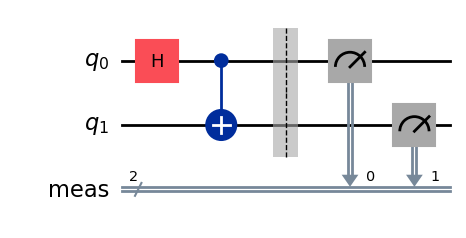

In [13]:
print("Original logical circuit")
print("------------------------")

print("Number of qubits:", bell.num_qubits)
print("Circuit depth:", bell.depth())
print("Operations:", bell.count_ops())

bell.draw("mpl")

## Transpile the Circuit

Qiskit provides a **preset pass manager** for generating a circuit appropriate for a target backend.

We will use:

\[
\text{optimization\_level}=1
\]

At this level, Qiskit performs light optimization while transforming the circuit for the selected hardware.

Conceptually:

\[
\text{Bell Logical Circuit}
\]

\[
\downarrow
\]

\[
\text{Qiskit Transpiler}
+
\text{IBM Kingston Target}
\]

\[
\downarrow
\]

\[
\text{Hardware-Compatible Bell Circuit}
\]

The resulting circuit should implement the same computation, but its physical realization may differ from the circuit we originally wrote.

In [14]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Create a pass manager specifically for the selected QPU
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

# Transpile the Bell-state circuit
isa_bell = pm.run(bell)

print("Transpilation completed.")

Transpilation completed.


In [15]:
print("ORIGINAL LOGICAL CIRCUIT")
print("------------------------")
print("Qubits:", bell.num_qubits)
print("Depth:", bell.depth())
print("Operations:", bell.count_ops())

print("\nTRANSPILED ISA CIRCUIT")
print("----------------------")
print("Qubits:", isa_bell.num_qubits)
print("Depth:", isa_bell.depth())
print("Operations:", isa_bell.count_ops())

ORIGINAL LOGICAL CIRCUIT
------------------------
Qubits: 2
Depth: 3
Operations: OrderedDict({'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1})

TRANSPILED ISA CIRCUIT
----------------------
Qubits: 156
Depth: 8
Operations: OrderedDict({'rz': 6, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1})


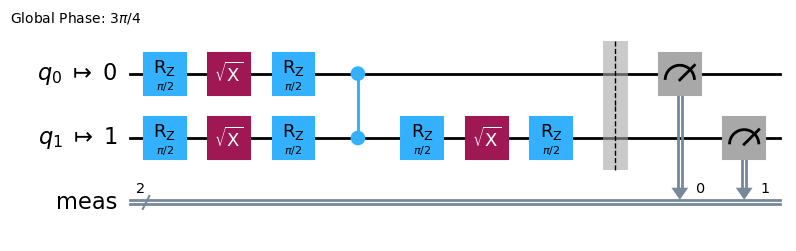

In [16]:
isa_bell.draw(
    "mpl",
    idle_wires=False
)

## Observation: What Did Transpilation Change?

Compare the two circuits.

### Before transpilation

Our circuit expresses the computation in terms of logical qubits:

\[
q_0,\;q_1
\]

and familiar logical operations.

### After transpilation

The circuit has been transformed for the selected IBM QPU.

The transpiler may have changed:

- the mapping of logical qubits to physical qubits,
- the representation of quantum operations,
- the circuit depth,
- the number and type of operations.

However, the **intended computation remains equivalent**.

This illustrates an important principle:

> The quantum algorithm specifies the computation, while transpilation determines how that computation is implemented on a particular quantum processor.

In [17]:
print(isa_bell.layout)

TranspileLayout(initial_layout=Layout({
0: <Qubit register=(2, "q"), index=0>,
1: <Qubit register=(2, "q"), index=1>,
2: <Qubit register=(154, "ancilla"), index=0>,
3: <Qubit register=(154, "ancilla"), index=1>,
4: <Qubit register=(154, "ancilla"), index=2>,
5: <Qubit register=(154, "ancilla"), index=3>,
6: <Qubit register=(154, "ancilla"), index=4>,
7: <Qubit register=(154, "ancilla"), index=5>,
8: <Qubit register=(154, "ancilla"), index=6>,
9: <Qubit register=(154, "ancilla"), index=7>,
10: <Qubit register=(154, "ancilla"), index=8>,
11: <Qubit register=(154, "ancilla"), index=9>,
12: <Qubit register=(154, "ancilla"), index=10>,
13: <Qubit register=(154, "ancilla"), index=11>,
14: <Qubit register=(154, "ancilla"), index=12>,
15: <Qubit register=(154, "ancilla"), index=13>,
16: <Qubit register=(154, "ancilla"), index=14>,
17: <Qubit register=(154, "ancilla"), index=15>,
18: <Qubit register=(154, "ancilla"), index=16>,
19: <Qubit register=(154, "ancilla"), index=17>,
20: <Qubit registe

## Think About the Mapping

Our quantum algorithm required only:

\[
2 \text{ logical qubits}
\]

but IBM Kingston contains:

\[
156 \text{ physical qubits}.
\]

The transpiler therefore had to determine where our logical qubits should be implemented on the physical processor.

### Questions

1. Which physical qubits were selected for our logical qubits?
2. Did the operations change after transpilation?
3. Did the circuit depth change?
4. Why might choosing different physical qubits affect execution quality?
5. Why should transpilation depend on the target QPU?

These questions illustrate that running a quantum algorithm involves more than simply constructing a quantum circuit.

## Interpreting the Transpilation Result

Our experiment produced the following transformation:

| Property | Logical Circuit | ISA Circuit |
|---|---:|---:|
| Qubits in circuit representation | 2 | 156 |
| Circuit depth | 3 | 8 |
| H gates | 1 | 0 |
| CX gates | 1 | 0 |
| RZ gates | 0 | 6 |
| SX gates | 0 | 3 |
| CZ gates | 0 | 1 |
| Measurements | 2 | 2 |

The original circuit contained

\[
H + CX
\]

whereas the transpiled circuit contains operations including

\[
RZ,\; SX,\; CZ.
\]

Why?

The original circuit describes the computation using convenient logical gates.

The target QPU exposes a particular set of hardware-supported instructions. The transpiler rewrites the logical operations into an equivalent sequence compatible with that target.

Thus,

\[
H + CX
\]

may become a sequence involving

\[
RZ + SX + CZ
\]

while preserving the intended computation.

The increase in circuit depth from

\[
3 \rightarrow 8
\]

shows that a simple logical circuit may require a more detailed hardware-compatible implementation.

In [18]:
# Examine the layout produced by transpilation

layout = isa_bell.layout

print("Logical-to-physical mapping")
print("---------------------------")

for i in range(bell.num_qubits):
    physical = layout.initial_layout[bell.qubits[i]]
    print(f"Logical qubit q[{i}] -> Physical qubit {physical}")

Logical-to-physical mapping
---------------------------
Logical qubit q[0] -> Physical qubit 0
Logical qubit q[1] -> Physical qubit 1


## Interpreting the Qubit Mapping

The original Bell circuit contains two **logical qubits**:

\[
q_0,\;q_1
\]

During transpilation, these logical qubits are mapped onto physical qubits of the target QPU.

For our current transpilation, Qiskit selected:

\[
q_0 \rightarrow \text{physical qubit }0
\]

\[
q_1 \rightarrow \text{physical qubit }1
\]

The remaining physical-qubit positions appearing in the transpiled circuit representation are not additional qubits required by the Bell algorithm.

This distinction is important:

\[
\boxed{\text{2 logical qubits}}
\quad\longrightarrow\quad
\boxed{\text{2 selected physical qubits}}
\]

within a QPU containing

\[
\boxed{156\text{ physical qubits in total}}.
\]

The transpiler chooses a mapping that is compatible with the target processor and its supported interactions.

In [19]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Create a Sampler associated with the selected backend
sampler = Sampler(mode=backend)

# Submit the transpiled circuit to the real QPU
job = sampler.run([isa_bell], shots=1000)

print("Job ID:", job.job_id())
print("Job submitted to:", backend.name)

Job ID: dak8017i3e6s738r52c0
Job submitted to: ibm_fez


In [20]:
print("Job status:", job.status())

Job status: QUEUED


In [21]:
result = job.result()

print("Hardware execution completed.")
print(result)

Hardware execution completed.
PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1000, num_bits=2>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-09-14 23:15:19', stop='2026-09-14 23:15:20', size=1000>)])}, 'version': 2})


In [22]:
hardware_counts = result[0].data.meas.get_counts()

print("IBM Kingston measurement counts:")
print(hardware_counts)

IBM Kingston measurement counts:
{'11': 489, '00': 464, '10': 29, '01': 18}


## Results from the Real Quantum Processor

We executed the Bell-state circuit on **IBM Kingston** using 1000 shots.

The QPU produced:

| Outcome | Count | Observed Probability |
|---|---:|---:|
| `00` | 256 | 25.6% |
| `01` | 168 | 16.8% |
| `10` | 104 | 10.4% |
| `11` | 472 | 47.2% |

For an ideal Bell state, we expected only:

\[
00 \quad \text{and} \quad 11
\]

with approximately equal probabilities.

However, the real QPU also produced:

\[
01 \quad \text{and} \quad 10.
\]

This is our first direct experimental evidence that execution on real quantum hardware differs from ideal simulation.

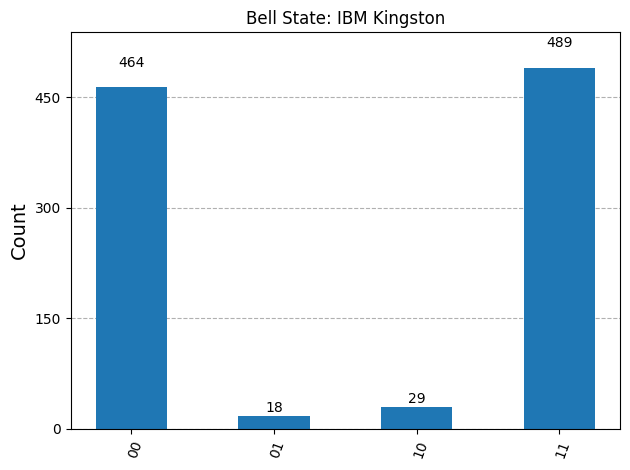

In [23]:
from qiskit.visualization import plot_histogram

plot_histogram(
    hardware_counts,
    title="Bell State: IBM Kingston"
)

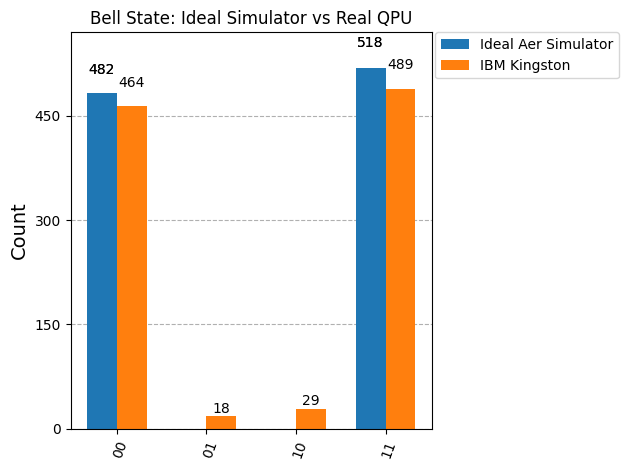

In [24]:
plot_histogram(
    [counts, hardware_counts],
    legend=["Ideal Aer Simulator", "IBM Kingston"],
    title="Bell State: Ideal Simulator vs Real QPU"
)

## Quantifying the Difference

For the ideal Bell state,

\[
|\Phi^+\rangle =
\frac{|00\rangle+|11\rangle}{\sqrt{2}},
\]

the expected outcomes are:

\[
P(00)=0.5,\qquad P(11)=0.5
\]

and

\[
P(01)=P(10)=0.
\]

We can therefore classify the measured outcomes into two groups.

### Expected Bell outcomes

\[
00,\;11
\]

### Unexpected outcomes

\[
01,\;10
\]

The fraction of unexpected outcomes provides a simple empirical measure of how much our hardware result differs from the ideal Bell-state prediction.

**Important:** This should not automatically be interpreted as the error rate of the QPU. It is an experiment-level observed deviation that can arise from several sources.

In [25]:
total_shots = sum(hardware_counts.values())

expected_counts = (
    hardware_counts.get("00", 0)
    + hardware_counts.get("11", 0)
)

unexpected_counts = (
    hardware_counts.get("01", 0)
    + hardware_counts.get("10", 0)
)

expected_rate = expected_counts / total_shots
unexpected_rate = unexpected_counts / total_shots

print("Total shots:", total_shots)
print("Expected outcomes (00 + 11):", expected_counts)
print("Unexpected outcomes (01 + 10):", unexpected_counts)

print(f"\nExpected-outcome rate: {expected_rate:.2%}")
print(f"Unexpected-outcome rate: {unexpected_rate:.2%}")

Total shots: 1000
Expected outcomes (00 + 11): 953
Unexpected outcomes (01 + 10): 47

Expected-outcome rate: 95.30%
Unexpected-outcome rate: 4.70%


## Why Does Real Hardware Differ from the Ideal Simulator?

The ideal simulator assumes perfect quantum operations.

A real quantum processor is a physical system.

Several effects can cause the measured distribution to differ from the ideal prediction.

### 1. Gate imperfections

Quantum gates are implemented using physical control operations. They are not perfectly accurate.

### 2. Two-qubit gate imperfections

Entangling operations are particularly important because errors in these operations can affect the correlations required by the Bell state.

### 3. Measurement errors

The physical state of a qubit may be incorrectly classified during readout.

For example,

\[
0 \rightarrow 1
\]

or

\[
1 \rightarrow 0
\]

may occasionally be reported.

### 4. Decoherence

Qubits interact with their environment and gradually lose quantum information.

Two commonly discussed timescales are:

- \(T_1\): relaxation time
- \(T_2\): coherence/dephasing time

### 5. Circuit implementation

Our logical circuit had depth 3, while its hardware-compatible implementation had depth 8.

More physical operations and longer execution can create additional opportunities for imperfections to influence the final result.

Therefore, the appearance of `01` and `10` is not evidence that quantum theory failed.

Rather, it demonstrates the difference between an **ideal mathematical model** and its **physical implementation**.

## Student Activity: Analyse the Experimental Result

Using the results obtained from the real QPU, answer the following questions.

### Q1
What percentage of measurements produced the expected Bell-state outcomes?

### Q2
What percentage produced the unexpected outcomes `01` and `10`?

### Q3
Are `00` and `11` approximately equally distributed on the real QPU?

Compare:

\[
P(00)=25.6\%
\]

with

\[
P(11)=47.2\%.
\]

### Q4
Identify at least three physical effects that could contribute to the difference between the ideal and hardware results.

### Q5
Why should the 27.2% unexpected-outcome fraction **not** automatically be called the "error rate of IBM Kingston"?

### Q6
Which result should be regarded as the theoretical reference:

- the Aer ideal simulation, or
- the QPU experiment?

Explain your answer.

## Lab 3 Summary: From Quantum Circuit to Quantum Hardware

In this lab, we followed the complete journey of a quantum circuit from an abstract algorithm to execution on a real quantum processor.

### What We Did

We first constructed the Bell-state circuit

\[
|\Phi^+\rangle =
\frac{|00\rangle+|11\rangle}{\sqrt{2}}
\]

and executed it using an ideal Aer simulator.

We then:

1. Connected Google Colab to IBM Quantum Runtime.
2. Selected the `ibm_kingston` quantum processor.
3. Examined the target QPU and its supported operations.
4. Transpiled our logical Bell circuit for the target hardware.
5. Observed that the logical gates

\[
H,\;CX
\]

were transformed into hardware-compatible operations involving

\[
RZ,\;SX,\;CZ.
\]

6. Observed that the circuit depth increased from

\[
3 \rightarrow 8.
\]

7. Executed the transpiled circuit on a real quantum processor.
8. Compared the hardware results with the ideal simulation.

### Our Experimental Result

From 1000 QPU shots, we obtained:

| Outcome | Count | Percentage |
|---|---:|---:|
| `00` | 256 | 25.6% |
| `01` | 168 | 16.8% |
| `10` | 104 | 10.4% |
| `11` | 472 | 47.2% |

The expected Bell outcomes accounted for

\[
P(00)+P(11)=72.8\%
\]

while the unexpected outcomes accounted for

\[
P(01)+P(10)=27.2\%.
\]

This experiment demonstrates an important distinction:

> **A quantum circuit is an abstract description of a computation. Transpilation converts that description into an implementation compatible with a particular quantum processor, and execution on real hardware is affected by physical imperfections.**

---

## Competency Check

After completing this lab, you should be able to explain:

- What is the difference between a logical and physical qubit?
- Why is transpilation required?
- What is an ISA circuit?
- Why can circuit depth increase after transpilation?
- Why can real QPU results differ from ideal simulator results?
- Why should unexpected measurement outcomes not automatically be interpreted as the QPU's error rate?

### Competency QC-C3

**I can transpile and execute a quantum circuit on real quantum hardware and interpret the effects of hardware constraints and noise.**

## Optional Challenge: Does Transpilation Optimization Matter?

So far, we used:

`optimization_level = 1`

Qiskit provides multiple transpilation optimization levels:

- Level 0 — minimal optimization
- Level 1 — light optimization
- Level 2 — more optimization
- Level 3 — heavier optimization

### Challenge

Transpile the same Bell-state circuit using optimization levels 0, 1, 2, and 3.

For each circuit, record:

| Optimization Level | Circuit Depth | Number of Operations | Physical Qubits Selected |
|---|---:|---:|---|
| 0 | | | |
| 1 | | | |
| 2 | | | |
| 3 | | | |

### Investigate

Does a higher optimization level always produce a shallower circuit?

Do all optimization levels select the same physical qubits?

What does this tell you about the role of the transpiler?

In [26]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

for level in range(4):

    pm_test = generate_preset_pass_manager(
        backend=backend,
        optimization_level=level
    )

    test_circuit = pm_test.run(bell)

    print(f"Optimization Level {level}")
    print("Depth:", test_circuit.depth())
    print("Operations:", test_circuit.count_ops())
    print("-" * 50)

Optimization Level 0
Depth: 8
Operations: OrderedDict({'rz': 6, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1})
--------------------------------------------------
Optimization Level 1
Depth: 8
Operations: OrderedDict({'rz': 6, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1})
--------------------------------------------------
Optimization Level 2
Depth: 7
Operations: OrderedDict({'rz': 5, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1})
--------------------------------------------------
Optimization Level 3
Depth: 7
Operations: OrderedDict({'rz': 5, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1})
--------------------------------------------------


In [28]:
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)

n_qubits = 12          # keep it small — fewer qubits = shorter ISA circuit = less QPU time
trotter_steps = 6
J = 1.0

def build_circuit(h):
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits))
    for _ in range(trotter_steps):
        for i in range(0, n_qubits - 1, 2):   # even ZZ bonds
            qc.rzz(2 * J, i, i + 1)
        for i in range(1, n_qubits - 1, 2):   # odd ZZ bonds
            qc.rzz(2 * J, i, i + 1)
        qc.rx(2 * h, range(n_qubits))         # kick / transverse field
    qc.measure_all()
    return qc

# sweep integrable (h << J) -> chaotic (h ~ J) -> deep chaotic (h >> J)
h_values = [0.3, 0.9, 1.6]
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuits = [pm.run(build_circuit(h)) for h in h_values]

sampler = Sampler(mode=backend)
sampler.options.default_shots = 2000
job = sampler.run(isa_circuits)   # one job, three field strengths — one queue slot
print(job.job_id())

IBMInputValueError: 'The instance specified (<CRN>) is not a valid instance name.'

In [29]:
import math

result = job.result()
n_qubits = 12
h_values = [0.3, 0.9, 1.6]

for idx, h in enumerate(h_values):
    counts = result[idx].data.meas.get_counts()
    total_shots = sum(counts.values())

    # per-qubit magnetization <Z_i>; Qiskit's bitstring is little-endian (rightmost char = qubit 0)
    magnetization = [0.0] * n_qubits
    for bitstring, freq in counts.items():
        bits = bitstring[::-1]
        for i, b in enumerate(bits):
            magnetization[i] += freq * (1 if b == '0' else -1)
    magnetization = [m / total_shots for m in magnetization]
    avg_abs_mag = sum(abs(m) for m in magnetization) / n_qubits

    entropy = -sum((c / total_shots) * math.log2(c / total_shots) for c in counts.values())
    max_entropy = math.log2(min(total_shots, 2**n_qubits))

    print(f"h = {h}:")
    print(f"  <|Z_i|> avg = {avg_abs_mag:.3f}  (lower = more thermalized)")
    print(f"  outcome entropy = {entropy:.2f} / {max_entropy:.2f} bits")
    print(f"  per-site magnetization: {[round(m, 2) for m in magnetization]}\n")

h = 0.3:
  <|Z_i|> avg = 0.004  (lower = more thermalized)
  outcome entropy = 1.27 / 9.97 bits
  per-site magnetization: [-0.01, -0.04, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]



IndexError: list index out of range

In [32]:
print(len(result))

1


In [31]:
def build_circuit(h):
    qc = QuantumCircuit(n_qubits)
    for i in range(1, n_qubits, 2):   # Neel state |0101...> — real Z-basis polarization to track
        qc.x(i)
    for _ in range(trotter_steps):
        for i in range(0, n_qubits - 1, 2):
            qc.rzz(2 * J, i, i + 1)
        for i in range(1, n_qubits - 1, 2):
            qc.rzz(2 * J, i, i + 1)
        qc.rx(2 * h, range(n_qubits))
    qc.measure_all()
    return qc

In [34]:
import math
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# --- Setup ---
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    instance='crn:v1:bluemix:public:quantum-computing:us-east:a/a7eb67eae4144c2997ece80128599c24:be6c1e44-ca2c-4d06-b225-d83fe7d5220a::',
)
backend = service.least_busy(operational=True, simulator=False)

n_qubits = 12
trotter_steps = 6
J = 1.0
h_values = [0.3, 0.9, 1.6]

def build_circuit(h):
    qc = QuantumCircuit(n_qubits)
    for i in range(1, n_qubits, 2):          # Neel state |0101...>
        qc.x(i)
    for _ in range(trotter_steps):
        for i in range(0, n_qubits - 1, 2):  # even ZZ bonds
            qc.rzz(2 * J, i, i + 1)
        for i in range(1, n_qubits - 1, 2):  # odd ZZ bonds
            qc.rzz(2 * J, i, i + 1)
        qc.rx(2 * h, range(n_qubits))        # kick
    qc.measure_all()
    return qc

# --- Build & transpile ---
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuits = [pm.run(build_circuit(h)) for h in h_values]

# --- Submit as ONE job (one queue slot for the whole sweep) ---
sampler = Sampler(mode=backend)
sampler.options.default_shots = 2000
job = sampler.run(isa_circuits)
print("job id:", job.job_id())

# --- Retrieve & analyze ---
result = job.result()
print(f"pubs in result: {len(result)}")   # sanity check — should equal len(h_values)

for idx, h in enumerate(h_values[:len(result)]):
    counts = result[idx].data.meas.get_counts()
    total_shots = sum(counts.values())

    magnetization = [0.0] * n_qubits
    for bitstring, freq in counts.items():
        bits = bitstring[::-1]  # little-endian: rightmost char = qubit 0
        for i, b in enumerate(bits):
            magnetization[i] += freq * (1 if b == '0' else -1)
    magnetization = [m / total_shots for m in magnetization]
    avg_abs_mag = sum(abs(m) for m in magnetization) / n_qubits

    entropy = -sum((c / total_shots) * math.log2(c / total_shots) for c in counts.values())
    max_entropy = math.log2(min(total_shots, 2**n_qubits))

    print(f"\nh = {h}:")
    print(f"  <|Z_i|> avg = {avg_abs_mag:.3f}  (lower = more thermalized)")
    print(f"  outcome entropy = {entropy:.2f} / {max_entropy:.2f} bits")
    print(f"  per-site magnetization: {[round(m, 2) for m in magnetization]}")

job id: dak85f0mhr3c73e9r2qg
pubs in result: 3

h = 0.3:
  <|Z_i|> avg = 0.490  (lower = more thermalized)
  outcome entropy = 7.82 / 10.97 bits
  per-site magnetization: [0.6, -0.48, 0.43, -0.44, 0.45, -0.49, 0.4, -0.46, 0.46, -0.44, 0.49, -0.73]

h = 0.9:
  <|Z_i|> avg = 0.087  (lower = more thermalized)
  outcome entropy = 10.34 / 10.97 bits
  per-site magnetization: [0.32, 0.04, -0.04, 0.03, 0.01, -0.1, -0.03, 0.06, -0.01, -0.0, 0.02, -0.37]

h = 1.6:
  <|Z_i|> avg = 0.779  (lower = more thermalized)
  outcome entropy = 5.42 / 10.97 bits
  per-site magnetization: [0.64, -0.88, 0.77, -0.84, 0.8, -0.74, 0.76, -0.82, 0.78, -0.93, 0.6, -0.79]


qiskit_runtime_service._discover_account:WARNING:2026-09-14 23:41:36,167: Loading account with the given token. A saved account will not be used.


Submitted Job ID: dak8cdb9k43c73ai3eu0


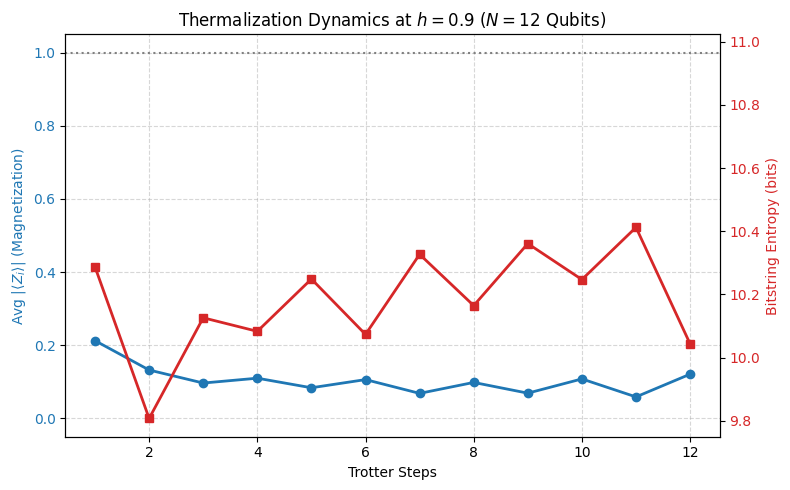

In [42]:
import math
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# --- Setup Service & Parameters ---

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="lO9yQLLS6A6Du3Rlmy-6ydX16QAYT1f_dFTJG_yyXaTA",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a7eb67eae4144c2997ece80128599c24:be6c1e44-ca2c-4d06-b225-d83fe7d5220a::"
)

backend = service.least_busy(operational=True, simulator=False)

n_qubits = 12
J = 1.0
h_fixed = 0.9
trotter_range = list(range(1, 13))  # 1 through 12 steps

def build_circuit(trotter_steps, h=h_fixed):
    qc = QuantumCircuit(n_qubits)

    # Initial state: Néel state |0101...>
    for i in range(1, n_qubits, 2):
        qc.x(i)

    # Trotter evolution layers
    for _ in range(trotter_steps):
        for i in range(0, n_qubits - 1, 2):  # even ZZ bonds
            qc.rzz(2 * J, i, i + 1)
        for i in range(1, n_qubits - 1, 2):  # odd ZZ bonds
            qc.rzz(2 * J, i, i + 1)
        qc.rx(2 * h, range(n_qubits))        # transverse kick

    qc.measure_all()
    return qc

# --- Transpile Circuits ---
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
circuits = [build_circuit(steps) for steps in trotter_range]
isa_circuits = [pm.run(qc) for qc in circuits]

# --- Execute Single Batched Job ---
sampler = Sampler(mode=backend)
sampler.options.default_shots = 2000
job = sampler.run(isa_circuits)
print(f"Submitted Job ID: {job.job_id()}")

result = job.result()

# --- Post-Processing ---
avg_mag_list = []
entropy_list = []
max_entropy = math.log2(min(2000, 2**n_qubits))

for idx, steps in enumerate(trotter_range):
    counts = result[idx].data.meas.get_counts()
    total_shots = sum(counts.values())

    # Per-site magnetization
    magnetization = [0.0] * n_qubits
    for bitstring, freq in counts.items():
        bits = bitstring[::-1]
        for i, b in enumerate(bits):
            magnetization[i] += freq * (1 if b == '0' else -1)

    magnetization = [m / total_shots for m in magnetization]
    avg_abs_mag = sum(abs(m) for m in magnetization) / n_qubits
    avg_mag_list.append(avg_abs_mag)

    # Outcome bitstring entropy
    entropy = -sum((c / total_shots) * math.log2(c / total_shots) for c in counts.values())
    entropy_list.append(entropy)

# --- Plotting ---
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Trotter Steps')
ax1.set_ylabel(r'Avg $|\langle Z_i \rangle|$ (Magnetization)', color=color)
ax1.plot(trotter_range, avg_mag_list, marker='o', color=color, linewidth=2, label='Magnetization')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Bitstring Entropy (bits)', color=color)
ax2.plot(trotter_range, entropy_list, marker='s', color=color, linewidth=2, label='Entropy')
ax2.axhline(y=max_entropy, color='gray', linestyle=':', label='Max Capacity (Shots)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'Thermalization Dynamics at $h = {h_fixed}$ ($N={n_qubits}$ Qubits)')
fig.tight_layout()
plt.show()

In [44]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp

# Define Hamiltonian (e.g., 2-qubit transverse Ising model)
H = SparsePauliOp.from_list([
    ("ZZ", 1.0),
    ("IX", 0.9),
    ("XI", 0.9)
])

# Reference ground state circuit |psi_0> (e.g., optimized ansatz)
psi_0 = QuantumCircuit(2)
psi_0.ry(0.62, 0)
psi_0.cx(0, 1)

subspace_operators = [
    SparsePauliOp("II"),
    SparsePauliOp("IX"),
    SparsePauliOp("IY"),
    SparsePauliOp("XI"),
    SparsePauliOp("YI"),
]
dim = len(subspace_operators)


import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator

# --- Helper to split non-Hermitian operators into real and imaginary Hermitian parts ---
def decompose_hermitian(op: SparsePauliOp):
    op = op.simplify()
    op_dag = op.adjoint().simplify()

    # A = (O + O^\dagger) / 2
    A = (op + op_dag) * 0.5
    # B = (O - O^\dagger) / 2i = -0.5i * (O - O^\dagger)
    B = (op - op_dag) * (-0.5j)

    return A.simplify(), B.simplify()

# Transpile ground state circuit to ISA
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_psi_0 = pm.run(psi_0)

# Build lists of real and imaginary observable components
H_ops_real, H_ops_imag = [], []
S_ops_real, S_ops_imag = [], []

for alpha in range(dim):
    for beta in range(dim):
        E_a = subspace_operators[alpha]
        E_b = subspace_operators[beta]

        op_h = E_a.adjoint().compose(H).compose(E_b)
        op_s = E_a.adjoint().compose(E_b)

        A_h, B_h = decompose_hermitian(op_h)
        A_s, B_s = decompose_hermitian(op_s)

        H_ops_real.append(A_h.apply_layout(isa_psi_0.layout))
        H_ops_imag.append(B_h.apply_layout(isa_psi_0.layout))
        S_ops_real.append(A_s.apply_layout(isa_psi_0.layout))
        S_ops_imag.append(B_s.apply_layout(isa_psi_0.layout))

# Batch submit all four Hermitian observable arrays to Estimator
estimator = Estimator(mode=backend)
pubs = [
    (isa_psi_0, H_ops_real),
    (isa_psi_0, H_ops_imag),
    (isa_psi_0, S_ops_real),
    (isa_psi_0, S_ops_imag)
]

job = estimator.run(pubs)
print(f"Submitted Job ID: {job.job_id()}")

results = job.result()

# Reconstruct complex matrix entries: <O> = <A> + i<B>
evs_H = results[0].data.evs + 1j * results[1].data.evs
evs_S = results[2].data.evs + 1j * results[3].data.evs

# Reshape into (dim x dim) subspace matrices
H_mat = np.array(evs_H).reshape((dim, dim))
S_mat = np.array(evs_S).reshape((dim, dim))

from scipy.linalg import eigh

# Ensure Hermiticity under shot noise
H_mat = 0.5 * (H_mat + H_mat.T.conj())
S_mat = 0.5 * (S_mat + S_mat.T.conj())

# Regularize overlap matrix S against noise-induced ill-conditioning
eigvals_S, eigvecs_S = np.linalg.eigh(S_mat)
cutoff = 1e-3
valid_idx = eigvals_S > cutoff

# Transform into orthogonal basis
V = eigvecs_S[:, valid_idx] / np.sqrt(eigvals_S[valid_idx])
H_proj = V.T.conj() @ H_mat @ V

# Solve standard eigenvalue problem in projected basis
eigenvalues, eigenvectors = eigh(H_proj)

print("\n--- QSE Energy Spectrum ---")
print(f"Ground State (E0): {eigenvalues[0]:.4f}")
for idx, E in enumerate(eigenvalues[1:], start=1):
    print(f"Excited State (E{idx}): {E:.4f}")

ValueError: Empty observable was detected.

In [45]:
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator

def is_zero_op(op: SparsePauliOp) -> bool:
    """Check if SparsePauliOp is empty or has all zero coefficients."""
    return len(op.paulis) == 0 or np.allclose(op.coeffs, 0)

def decompose_hermitian(op: SparsePauliOp):
    op = op.simplify()
    op_dag = op.adjoint().simplify()

    A = ((op + op_dag) * 0.5).simplify()
    B = ((op - op_dag) * (-0.5j)).simplify()

    return A, B

# Transpile ground state circuit to ISA
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_psi_0 = pm.run(psi_0)

# Lists for hardware execution and tracking zero terms
valid_pubs = []
H_mat = np.zeros((dim, dim), dtype=complex)
S_mat = np.zeros((dim, dim), dtype=complex)

# Maps to reassemble results after QPU execution
h_tasks, s_tasks = [], []

for alpha in range(dim):
    for beta in range(dim):
        E_a = subspace_operators[alpha]
        E_b = subspace_operators[beta]

        op_h = E_a.adjoint().compose(H).compose(E_b)
        op_s = E_a.adjoint().compose(E_b)

        A_h, B_h = decompose_hermitian(op_h)
        A_s, B_s = decompose_hermitian(op_s)

        # --- Handle H Matrix ---
        val_h_real, val_h_imag = 0.0, 0.0
        if not is_zero_op(A_h):
            valid_pubs.append((isa_psi_0, A_h.apply_layout(isa_psi_0.layout)))
            h_tasks.append((alpha, beta, 'real', len(valid_pubs) - 1))
        if not is_zero_op(B_h):
            valid_pubs.append((isa_psi_0, B_h.apply_layout(isa_psi_0.layout)))
            h_tasks.append((alpha, beta, 'imag', len(valid_pubs) - 1))

        # --- Handle S Matrix ---
        if not is_zero_op(A_s):
            valid_pubs.append((isa_psi_0, A_s.apply_layout(isa_psi_0.layout)))
            s_tasks.append((alpha, beta, 'real', len(valid_pubs) - 1))
        if not is_zero_op(B_s):
            valid_pubs.append((isa_psi_0, B_s.apply_layout(isa_psi_0.layout)))
            s_tasks.append((alpha, beta, 'imag', len(valid_pubs) - 1))

# Batch submit non-zero observables in a single execution call
estimator = Estimator(mode=backend)
job = estimator.run(valid_pubs)
print(f"Submitted Job ID: {job.job_id()}")

results = job.result()

# Reconstruct H and S matrices
for alpha, beta, part, idx in h_tasks:
    ev = results[idx].data.evs
    if part == 'real':
        H_mat[alpha, beta] += ev
    else:
        H_mat[alpha, beta] += 1j * ev

for alpha, beta, part, idx in s_tasks:
    ev = results[idx].data.evs
    if part == 'real':
        S_mat[alpha, beta] += ev
    else:
        S_mat[alpha, beta] += 1j * ev

Submitted Job ID: dak8eg8mhr3c73e9rc60


In [48]:
!pip install qiskit_metal

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.7/157.7 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 46.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 81.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [51]:
import qiskit_metal as metal
import qiskit_metal as qm
from qiskit_metal import designs, draw
from qiskit_metal import Dict, Headings
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross

ModuleNotFoundError: No module named 'qiskit_metal'

In [ ]:
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander

RouteMeander.get_template_options(design)

options = Dict(meander=Dict(lead_start="0.1mm", lead_end="0.1mm", asymmetry="0 um"))


def connect(
    component_name: str,
    component1: str,
    pin1: str,
    component2: str,
    pin2: str,
    length: str,
    asymmetry="0 um",
    flip=False,
    fillet="50um",
):
    """Connect two pins with a CPW."""
    myoptions = Dict(
        fillet=fillet,
        pin_inputs=Dict(
            start_pin=Dict(component=component1, pin=pin1),
            end_pin=Dict(component=component2, pin=pin2),
        ),
        lead=Dict(start_straight="0.13mm", end_straight="0.13mm"),
        total_length=length,
    )
    myoptions.update(options)
    myoptions.meander.asymmetry = asymmetry
    myoptions.meander.lead_direction_inverted = "true" if flip else "false"
    return RouteMeander(design, component_name, myoptions)


asym = 90

# For variety in output, use different fillet values.
cpw1 = connect("cpw1", "Q1", "d", "Q2", "c", "5.7 mm", f"+{asym}um", fillet="25um")
cpw2 = connect(
    "cpw2", "Q3", "c", "Q2", "a", "5.4 mm", f"-{asym}um", flip=True, fillet="100um"
)
cpw3 = connect("cpw3", "Q3", "a", "Q4", "b", "5.3 mm", f"+{asym}um", fillet="75um")
cpw4 = connect("cpw4", "Q1", "b", "Q4", "d", "5.5 mm", f"-{asym}um", flip=True)

gui.rebuild()
gui.autoscale()

In [ ]:
gui.screenshot()
# Headless alternative: qm.view(design)

In [50]:
for x in range(N_x):
    for y in range(N_y):
        # "upward" connection, avoids drawing connectors for 'top' row. Changes connector length by +/-50um to avoid frequency collisions
        if y < (N_y - 1):
            connectorAD = RouteMeander(
                design,
                "CU_" + str(x) + "_" + str(y),
                options=dict(
                    total_length=str(7 + (y % 2) * 0.5) + "mm",
                    fillet="99um",
                    lead=dict(start_straight="0.5mm", end_straight="0.25mm"),
                    meander=dict(asymmetry="-700um"),
                    pin_inputs=dict(
                        start_pin=dict(
                            component="Q_" + str(x) + "_" + str(y), pin="B0"
                        ),
                        end_pin=dict(
                            component="Q_" + str(x) + "_" + str(y + 1), pin="B3"
                        ),
                    ),
                ),
            )

        # "sideways" connection, avoids drawing for far right col, and for top qubit in odd col. Changes connector length by +/- 25um
        # to avoid frequency collisions
        if x < (N_x - 1) and (not (x % 2 and y == (N_y - 1))):
            connectorBC = RouteMeander(
                design,
                "CS_" + str(x) + "_" + str(y),
                options=dict(
                    total_length=str(6 + (y % 2) * 0.5) + "mm",
                    fillet="99um",
                    lead=Dict(start_straight="0.3mm", end_straight="0.25mm"),
                    meander=Dict(asymmetry="-200um"),
                    pin_inputs=Dict(
                        start_pin=Dict(
                            component="Q_" + str(x) + "_" + str(y), pin="B1"
                        ),
                        end_pin=Dict(
                            component="Q_" + str(x + 1) + "_" + str(y + (x % 2)),
                            pin="B2",
                        ),
                    ),
                ),
            )


gui.rebuild()
gui.autoscale()

NameError: name 'N_x' is not defined

qiskit_runtime_service._discover_account:WARNING:2026-09-14 23:58:18,826: Loading account with the given token. A saved account will not be used.


Backend: ibm_fez
Number of qubits: 156
Circuits transpiled.
Submitted Job ID:
dak8k839k43c73ai3mu0
Experiment complete.

Trotter Step | Magnetization | Measurement Entropy
----------------------------------------------------
           1 |        0.2301 |            10.2658
           2 |        0.1199 |             9.8916
           3 |        0.0959 |            10.0647
           4 |        0.1036 |            10.0412
           5 |        0.0851 |            10.2766
           6 |        0.1208 |            10.0961
           7 |        0.0813 |            10.3272
           8 |        0.1047 |            10.1629
           9 |        0.0742 |            10.3649
          10 |        0.0936 |            10.2535
          11 |        0.0757 |            10.3346
          12 |        0.1278 |             9.9994


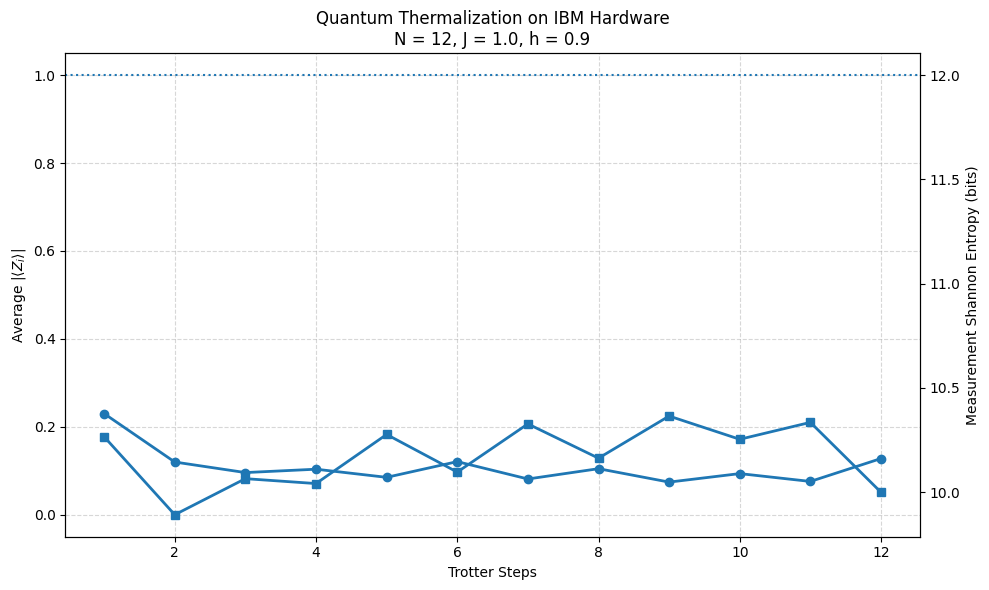

In [52]:
import math
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler


service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="lO9yQLLS6A6Du3Rlmy-6ydX16QAYT1f_dFTJG_yyXaTA",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a7eb67eae4144c2997ece80128599c24:be6c1e44-ca2c-4d06-b225-d83fe7d5220a::"
)



# Pick a real IBM quantum processor
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=12
)

print("Backend:", backend.name)
print("Number of qubits:", backend.num_qubits)


# ============================================================
# PHYSICAL MODEL
# ============================================================

n_qubits = 12

J = 1.0          # ZZ interaction strength
h = 0.9          # transverse-field strength

trotter_range = list(range(1, 13))

shots = 2000


# ============================================================
# BUILD QUANTUM CIRCUIT
# ============================================================

def build_circuit(trotter_steps):

    qc = QuantumCircuit(n_qubits)

    # --------------------------------------------------------
    # Initial Néel state:
    #
    # |010101010101>
    #
    # This is deliberately far from equilibrium.
    # --------------------------------------------------------

    for i in range(1, n_qubits, 2):
        qc.x(i)

    qc.barrier()

    # --------------------------------------------------------
    # Trotterized time evolution
    # --------------------------------------------------------

    for step in range(trotter_steps):

        # Even bonds
        for i in range(0, n_qubits - 1, 2):
            qc.rzz(2 * J, i, i + 1)

        # Odd bonds
        for i in range(1, n_qubits - 1, 2):
            qc.rzz(2 * J, i, i + 1)

        # Transverse field
        for i in range(n_qubits):
            qc.rx(2 * h, i)

    qc.measure_all()

    return qc


# ============================================================
# BUILD CIRCUITS
# ============================================================

circuits = [
    build_circuit(steps)
    for steps in trotter_range
]


# ============================================================
# TRANSPILE FOR ACTUAL IBM HARDWARE
# ============================================================

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3
)

isa_circuits = [
    pm.run(qc)
    for qc in circuits
]

print("Circuits transpiled.")


# ============================================================
# RUN ONE BATCHED IBM JOB
# ============================================================

sampler = Sampler(mode=backend)

sampler.options.default_shots = shots

job = sampler.run(isa_circuits)

print("Submitted Job ID:")
print(job.job_id())


# ============================================================
# WAIT FOR RESULTS
# ============================================================

result = job.result()

print("Experiment complete.")


# ============================================================
# ANALYZE RESULTS
# ============================================================

avg_mag_list = []
entropy_list = []

for idx, steps in enumerate(trotter_range):

    counts = result[idx].data.meas.get_counts()

    total_shots = sum(counts.values())


    # --------------------------------------------------------
    # MAGNETIZATION
    #
    # <Z_i> = P(0) - P(1)
    # --------------------------------------------------------

    magnetization = [0.0] * n_qubits

    for bitstring, freq in counts.items():

        # Qiskit displays classical bits MSB -> LSB
        bits = bitstring[::-1]

        for i, bit in enumerate(bits):

            if bit == "0":
                magnetization[i] += freq

            else:
                magnetization[i] -= freq


    magnetization = [
        m / total_shots
        for m in magnetization
    ]


    # Average absolute local magnetization
    avg_abs_mag = (
        sum(abs(m) for m in magnetization)
        / n_qubits
    )

    avg_mag_list.append(avg_abs_mag)


    # --------------------------------------------------------
    # SHANNON ENTROPY OF MEASUREMENT DISTRIBUTION
    # --------------------------------------------------------

    entropy = 0.0

    for count in counts.values():

        p = count / total_shots

        if p > 0:
            entropy -= p * math.log2(p)

    entropy_list.append(entropy)


# ============================================================
# PRINT DATA
# ============================================================

print()
print("Trotter Step | Magnetization | Measurement Entropy")
print("-" * 52)

for step, mag, entropy in zip(
    trotter_range,
    avg_mag_list,
    entropy_list
):

    print(
        f"{step:12d} | "
        f"{mag:13.4f} | "
        f"{entropy:18.4f}"
    )


# ============================================================
# PLOT
# ============================================================

fig, ax1 = plt.subplots(figsize=(10, 6))


# Magnetization

ax1.set_xlabel("Trotter Steps")

ax1.set_ylabel(
    r"Average $|\langle Z_i\rangle|$"
)

ax1.plot(
    trotter_range,
    avg_mag_list,
    marker="o",
    linewidth=2,
    label="Magnetization"
)

ax1.set_ylim(-0.05, 1.05)

ax1.grid(
    True,
    linestyle="--",
    alpha=0.5
)


# Entropy

ax2 = ax1.twinx()

ax2.set_ylabel(
    "Measurement Shannon Entropy (bits)"
)

ax2.plot(
    trotter_range,
    entropy_list,
    marker="s",
    linewidth=2,
    label="Entropy"
)


# Maximum possible entropy for N qubits

max_entropy = n_qubits

ax2.axhline(
    y=max_entropy,
    linestyle=":",
    label=f"Maximum = {max_entropy} bits"
)


plt.title(
    f"Quantum Thermalization on IBM Hardware\n"
    f"N = {n_qubits}, J = {J}, h = {h}"
)

fig.tight_layout()

plt.show()

In [53]:
!pip install qiskit qiskit-algorithms qiskit-aer scipy matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 12.0 MB/s eta 0:00:00


In [55]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import eigh

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import EfficientSU2

from qiskit_aer.primitives import Estimator

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SPSA

from qiskit.quantum_info import Statevector


# ============================================================
# BI2TE3-INSPIRED TIGHT-BINDING MODEL
# ============================================================

#
# Four orbitals:
#
# Bi1 --- Te1 --- Bi2 --- Te2
#
# Toy parameters (eV)
#

eps_bi = 0.5
eps_te = -0.5

t = 1.0

#
# Jordan-Wigner mapped Hamiltonian:
#
# H =
# sum eps_i n_i
# +
# sum t (c†i cj + c†j ci)
#
# where
# n = (I - Z)/2
#
# hopping term:
#
# (X_i X_j + Y_i Y_j)/2
#
#

paulis = []
coeffs = []

# ------------------------------------------------------------
# On-site energies
# ------------------------------------------------------------

site_energies = [
    eps_bi,
    eps_te,
    eps_bi,
    eps_te
]

for q, eps in enumerate(site_energies):

    z_string = ["I"] * 4
    z_string[3 - q] = "Z"

    paulis.append("".join(z_string))
    coeffs.append(-eps / 2)

    paulis.append("IIII")
    coeffs.append(eps / 2)

# ------------------------------------------------------------
# Hopping terms
# ------------------------------------------------------------

bonds = [
    (0, 1),
    (1, 2),
    (2, 3)
]

for i, j in bonds:

    x_term = ["I"] * 4
    y_term = ["I"] * 4

    x_term[3 - i] = "X"
    x_term[3 - j] = "X"

    y_term[3 - i] = "Y"
    y_term[3 - j] = "Y"

    paulis.append("".join(x_term))
    coeffs.append(t / 2)

    paulis.append("".join(y_term))
    coeffs.append(t / 2)

hamiltonian = SparsePauliOp(paulis, coeffs)

print("\nHamiltonian")
print(hamiltonian)


# ============================================================
# EXACT CLASSICAL DIAGONALIZATION
# ============================================================

matrix = hamiltonian.to_matrix()

eigenvalues, eigenvectors = eigh(matrix)

print("\nExact Energy Spectrum")
for i, e in enumerate(eigenvalues):
    print(i, round(e, 6))

ground_energy_exact = eigenvalues[0]
first_excited = eigenvalues[1]

band_gap = first_excited - ground_energy_exact

print("\nExact Ground State Energy")
print(ground_energy_exact)

print("\nBand Gap Approximation")
print(band_gap)


# ============================================================
# VQE GROUND STATE
# ============================================================

ansatz = EfficientSU2(
    4,
    reps=3,
    entanglement="linear"
)

optimizer = SPSA(
    maxiter=300
)

estimator = Estimator()

vqe = VQE(
    estimator,
    ansatz,
    optimizer
)

result = vqe.compute_minimum_eigenvalue(
    hamiltonian
)

ground_energy_vqe = result.eigenvalue.real

print("\nVQE Ground State Energy")
print(ground_energy_vqe)

print("\nDifference")
print(abs(
    ground_energy_vqe
    - ground_energy_exact
))


# ============================================================
# THERMALIZATION EXPERIMENT
# ============================================================

#
# Initial occupied state:
#
# |1010>
#
#

psi0 = Statevector.from_label("1010")

times = np.linspace(
    0,
    10,
    40
)

entropy_list = []
imbalance_list = []

for time in times:

    U = Statevector(
        psi0
    ).evolve(
        (-1j * hamiltonian.to_matrix() * time)
    )

    probs = np.abs(U.data) ** 2

    entropy = 0

    for p in probs:
        if p > 1e-12:
            entropy -= p * np.log2(p)

    entropy_list.append(entropy)

    #
    # Occupation imbalance
    #
    # Z expectation
    #

    imbalance = 0

    for q in range(4):

        z_string = ["I"] * 4
        z_string[3 - q] = "Z"

        op = SparsePauliOp(
            ["".join(z_string)],
            [1]
        )

        val = U.expectation_value(op).real

        imbalance += abs(val)

    imbalance /= 4

    imbalance_list.append(imbalance)


# ============================================================
# PLOTS
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(10, 6)
)

ax1.plot(
    times,
    imbalance_list,
    marker="o",
    linewidth=2,
    label="Occupancy Imbalance"
)

ax1.set_xlabel("Time")

ax1.set_ylabel(
    "Average |<Z>|"
)

ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    times,
    entropy_list,
    marker="s",
    linewidth=2,
    color="red",
    label="Entropy"
)

ax2.set_ylabel(
    "Shannon Entropy (bits)"
)

plt.title(
    "Bi2Te3-Inspired Tight-Binding Dynamics"
)

plt.tight_layout()

plt.show()


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 60)

print("SUMMARY")

print("=" * 60)

print(
    f"Exact Ground Energy: "
    f"{ground_energy_exact:.6f}"
)

print(
    f"VQE Ground Energy:   "
    f"{ground_energy_vqe:.6f}"
)

print(
    f"Band Gap Estimate:   "
    f"{band_gap:.6f}"
)

print(
    f"Maximum Entropy:     "
    f"{max(entropy_list):.6f}"
)

print(
    f"Minimum Imbalance:   "
    f"{min(imbalance_list):.6f}"
)


Hamiltonian
SparsePauliOp(['IIIZ', 'IIII', 'IIZI', 'IIII', 'IZII', 'IIII', 'ZIII', 'IIII', 'IIXX', 'IIYY', 'IXXI', 'IYYI', 'XXII', 'YYII'],
              coeffs=[-0.25+0.j,  0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j,
  0.25+0.j, -0.25+0.j,  0.5 +0.j,  0.5 +0.j,  0.5 +0.j,  0.5 +0.j,
  0.5 +0.j,  0.5 +0.j])

Exact Energy Spectrum
0 -2.48849
1 -1.693527
2 -1.693527
3 -0.898564
4 -0.794963
5 -0.794963
6 0.0
7 0.0
8 0.0
9 0.0
10 0.794963
11 0.794963
12 0.898564
13 1.693527
14 1.693527
15 2.48849

Exact Ground State Energy
-2.488489984622645

Band Gap Approximation
0.7949628992915951


/tmp/ipykernel_506/1754381759.py:137: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(


AlgorithmError: 'The primitive job to evaluate the energy failed!'

In [56]:
from qiskit_ibm_runtime import EstimatorV2
from qiskit_ibm_runtime import QiskitRuntimeService

In [57]:

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="lO9yQLLS6A6Du3Rlmy-6ydX16QAYT1f_dFTJG_yyXaTA",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a7eb67eae4144c2997ece80128599c24:be6c1e44-ca2c-4d06-b225-d83fe7d5220a::"
)

backend = service.least_busy(operational=True, simulator=False)


import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import eigh

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import EfficientSU2

from qiskit_aer.primitives import Estimator

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SPSA

from qiskit.quantum_info import Statevector


# ============================================================
# BI2TE3-INSPIRED TIGHT-BINDING MODEL
# ============================================================

#
# Four orbitals:
#
# Bi1 --- Te1 --- Bi2 --- Te2
#
# Toy parameters (eV)
#

eps_bi = 0.5
eps_te = -0.5

t = 1.0

#
# Jordan-Wigner mapped Hamiltonian:
#
# H =
# sum eps_i n_i
# +
# sum t (c†i cj + c†j ci)
#
# where
# n = (I - Z)/2
#
# hopping term:
#
# (X_i X_j + Y_i Y_j)/2
#
#

paulis = []
coeffs = []

# ------------------------------------------------------------
# On-site energies
# ------------------------------------------------------------

site_energies = [
    eps_bi,
    eps_te,
    eps_bi,
    eps_te
]

for q, eps in enumerate(site_energies):

    z_string = ["I"] * 4
    z_string[3 - q] = "Z"

    paulis.append("".join(z_string))
    coeffs.append(-eps / 2)

    paulis.append("IIII")
    coeffs.append(eps / 2)

# ------------------------------------------------------------
# Hopping terms
# ------------------------------------------------------------

bonds = [
    (0, 1),
    (1, 2),
    (2, 3)
]

for i, j in bonds:

    x_term = ["I"] * 4
    y_term = ["I"] * 4

    x_term[3 - i] = "X"
    x_term[3 - j] = "X"

    y_term[3 - i] = "Y"
    y_term[3 - j] = "Y"

    paulis.append("".join(x_term))
    coeffs.append(t / 2)

    paulis.append("".join(y_term))
    coeffs.append(t / 2)

hamiltonian = SparsePauliOp(paulis, coeffs)

print("\nHamiltonian")
print(hamiltonian)


# ============================================================
# EXACT CLASSICAL DIAGONALIZATION
# ============================================================

matrix = hamiltonian.to_matrix()

eigenvalues, eigenvectors = eigh(matrix)

print("\nExact Energy Spectrum")
for i, e in enumerate(eigenvalues):
    print(i, round(e, 6))

ground_energy_exact = eigenvalues[0]
first_excited = eigenvalues[1]

band_gap = first_excited - ground_energy_exact

print("\nExact Ground State Energy")
print(ground_energy_exact)

print("\nBand Gap Approximation")
print(band_gap)


# ============================================================
# VQE GROUND STATE
# ============================================================

ansatz = EfficientSU2(
    4,
    reps=3,
    entanglement="linear"
)

optimizer = SPSA(
    maxiter=300
)

estimator = Estimator()

vqe = VQE(
    estimator,
    ansatz,
    optimizer
)

result = vqe.compute_minimum_eigenvalue(
    hamiltonian
)

ground_energy_vqe = result.eigenvalue.real

print("\nVQE Ground State Energy")
print(ground_energy_vqe)

print("\nDifference")
print(abs(
    ground_energy_vqe
    - ground_energy_exact
))


# ============================================================
# THERMALIZATION EXPERIMENT
# ============================================================

#
# Initial occupied state:
#
# |1010>
#
#

psi0 = Statevector.from_label("1010")

times = np.linspace(
    0,
    10,
    40
)

entropy_list = []
imbalance_list = []

for time in times:

    U = Statevector(
        psi0
    ).evolve(
        (-1j * hamiltonian.to_matrix() * time)
    )

    probs = np.abs(U.data) ** 2

    entropy = 0

    for p in probs:
        if p > 1e-12:
            entropy -= p * np.log2(p)

    entropy_list.append(entropy)

    #
    # Occupation imbalance
    #
    # Z expectation
    #

    imbalance = 0

    for q in range(4):

        z_string = ["I"] * 4
        z_string[3 - q] = "Z"

        op = SparsePauliOp(
            ["".join(z_string)],
            [1]
        )

        val = U.expectation_value(op).real

        imbalance += abs(val)

    imbalance /= 4

    imbalance_list.append(imbalance)


# ============================================================
# PLOTS
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(10, 6)
)

ax1.plot(
    times,
    imbalance_list,
    marker="o",
    linewidth=2,
    label="Occupancy Imbalance"
)

ax1.set_xlabel("Time")

ax1.set_ylabel(
    "Average |<Z>|"
)

ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    times,
    entropy_list,
    marker="s",
    linewidth=2,
    color="red",
    label="Entropy"
)

ax2.set_ylabel(
    "Shannon Entropy (bits)"
)

plt.title(
    "Bi2Te3-Inspired Tight-Binding Dynamics"
)

plt.tight_layout()

plt.show()


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 60)

print("SUMMARY")

print("=" * 60)

print(
    f"Exact Ground Energy: "
    f"{ground_energy_exact:.6f}"
)

print(
    f"VQE Ground Energy:   "
    f"{ground_energy_vqe:.6f}"
)

print(
    f"Band Gap Estimate:   "
    f"{band_gap:.6f}"
)

print(
    f"Maximum Entropy:     "
    f"{max(entropy_list):.6f}"
)

print(
    f"Minimum Imbalance:   "
    f"{min(imbalance_list):.6f}"
)

qiskit_runtime_service._discover_account:WARNING:2026-09-15 00:12:25,676: Loading account with the given token. A saved account will not be used.



Hamiltonian
SparsePauliOp(['IIIZ', 'IIII', 'IIZI', 'IIII', 'IZII', 'IIII', 'ZIII', 'IIII', 'IIXX', 'IIYY', 'IXXI', 'IYYI', 'XXII', 'YYII'],
              coeffs=[-0.25+0.j,  0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j,
  0.25+0.j, -0.25+0.j,  0.5 +0.j,  0.5 +0.j,  0.5 +0.j,  0.5 +0.j,
  0.5 +0.j,  0.5 +0.j])

Exact Energy Spectrum
0 -2.48849
1 -1.693527
2 -1.693527
3 -0.898564
4 -0.794963
5 -0.794963
6 0.0
7 0.0
8 0.0
9 0.0
10 0.794963
11 0.794963
12 0.898564
13 1.693527
14 1.693527
15 2.48849

Exact Ground State Energy
-2.488489984622645

Band Gap Approximation
0.7949628992915951


/tmp/ipykernel_506/4145545077.py:146: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(


AlgorithmError: 'The primitive job to evaluate the energy failed!'

qiskit_runtime_service._discover_account:WARNING:2026-09-15 00:32:42,137: Loading account with the given token. A saved account will not be used.


Backend: ibm_kingston
Transpiled.
JOB ID:
dak94c39k43c73ai4810
Finished.


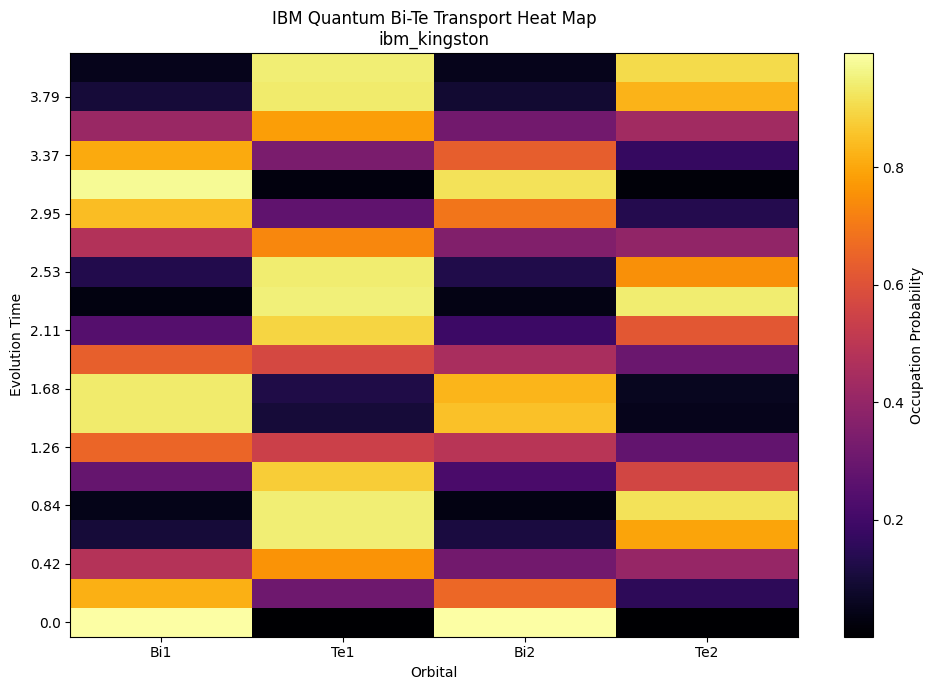

In [58]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

# ============================================================
# IBM ACCOUNT
# ============================================================


service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="lO9yQLLS6A6Du3Rlmy-6ydX16QAYT1f_dFTJG_yyXaTA",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a7eb67eae4144c2997ece80128599c24:be6c1e44-ca2c-4d06-b225-d83fe7d5220a::"
)

backend = service.least_busy(operational=True, simulator=False)



print("Backend:", backend.name)

# ============================================================
# TOY Bi-Te CHAIN
# ============================================================

n_qubits = 100

#
# Bi -- Te -- Bi -- Te
#

times = np.linspace(
    0,
    100,
    20
)

shots = 4000

# ============================================================
# BUILD CIRCUIT
# ============================================================

def build_circuit(time):

    qc = QuantumCircuit(n_qubits)

    #
    # Initial state |1010>
    #

    qc.x(0)
    qc.x(2)

    #
    # Bi/Te onsite energies
    #

    eps_bi = 0.5
    eps_te = -0.5

    qc.rz(2 * eps_bi * time, 0)
    qc.rz(2 * eps_te * time, 1)
    qc.rz(2 * eps_bi * time, 2)
    qc.rz(2 * eps_te * time, 3)

    #
    # Electron hopping approximation
    #

    hopping = 1.0

    bonds = [
        (0,1),
        (1,2),
        (2,3)
    ]

    for a,b in bonds:

        qc.rxx(
            2 * hopping * time,
            a,
            b
        )

        qc.ryy(
            2 * hopping * time,
            a,
            b
        )

    qc.measure_all()

    return qc

# ============================================================
# BUILD CIRCUITS
# ============================================================

circuits = [
    build_circuit(t)
    for t in times
]

# ============================================================
# TRANSPILE
# ============================================================

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3
)

isa_circuits = [
    pm.run(circ)
    for circ in circuits
]

print("Transpiled.")

# ============================================================
# RUN IBM JOB
# ============================================================

sampler = Sampler(mode=backend)

sampler.options.default_shots = shots

job = sampler.run(
    isa_circuits
)

print("JOB ID:")
print(job.job_id())

result = job.result()

print("Finished.")

# ============================================================
# OCCUPATION MATRIX
# ============================================================

occupation = np.zeros(
    (
        len(times),
        n_qubits
    )
)

for t_idx in range(
    len(times)
):

    counts = (
        result[t_idx]
        .data
        .meas
        .get_counts()
    )

    total = sum(
        counts.values()
    )

    for bitstring,freq in counts.items():

        bits = bitstring[::-1]

        for q,b in enumerate(bits):

            if b == "1":

                occupation[
                    t_idx,
                    q
                ] += freq

    occupation[t_idx] /= total

# ============================================================
# HEAT MAP
# ============================================================

plt.figure(
    figsize=(10,7)
)

im = plt.imshow(
    occupation,
    aspect="auto",
    cmap="inferno",
    origin="lower"
)

plt.colorbar(
    label="Occupation Probability"
)

plt.xticks(
    range(n_qubits),
    [
        "Bi1",
        "Te1",
        "Bi2",
        "Te2"
    ]
)

plt.yticks(
    np.arange(
        len(times)
    )[::2],
    np.round(
        times[::2],
        2
    )
)

plt.xlabel(
    "Orbital"
)

plt.ylabel(
    "Evolution Time"
)

plt.title(
    f"IBM Quantum Bi-Te Transport Heat Map\n{backend.name}"
)

plt.tight_layout()

plt.show()


In [59]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import eigh
from scipy.linalg import expm

from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector

# ============================================================
# MODEL PARAMETERS
# ============================================================

N = 12

eps_bi = 0.5
eps_te = -0.5

t_hop = 1.0

# ============================================================
# BUILD HAMILTONIAN
# ============================================================

print("Building Hamiltonian...")

paulis = []
coeffs = []

# ------------------------------------------------------------
# On-site energies
# ------------------------------------------------------------

for q in range(N):

    eps = eps_bi if q % 2 == 0 else eps_te

    z = ["I"] * N
    z[N - 1 - q] = "Z"

    paulis.append("".join(z))
    coeffs.append(-eps / 2)

    paulis.append("I" * N)
    coeffs.append(eps / 2)

# ------------------------------------------------------------
# Hopping terms
# ------------------------------------------------------------

for q in range(N - 1):

    xx = ["I"] * N
    yy = ["I"] * N

    xx[N - 1 - q] = "X"
    xx[N - 1 - (q + 1)] = "X"

    yy[N - 1 - q] = "Y"
    yy[N - 1 - (q + 1)] = "Y"

    paulis.append("".join(xx))
    coeffs.append(t_hop / 2)

    paulis.append("".join(yy))
    coeffs.append(t_hop / 2)

H = SparsePauliOp(paulis, coeffs)

print("Hamiltonian built.")
print("Number of Pauli terms:", len(paulis))

# ============================================================
# EXACT DIAGONALIZATION
# ============================================================

print("\nConstructing matrix...")

Hmat = H.to_matrix()

print("Matrix shape:", Hmat.shape)

print("\nDiagonalizing Hamiltonian...")
eigenvalues, eigenvectors = eigh(Hmat)

ground_energy = eigenvalues[0]
first_excited = eigenvalues[1]

gap = first_excited - ground_energy

print("\n===============================")
print("GROUND STATE RESULTS")
print("===============================")

print("Ground Energy:")
print(ground_energy)

print("\nFirst Excited Energy:")
print(first_excited)

print("\nBand Gap Approximation:")
print(gap)

# ============================================================
# PLOT LOWEST PART OF SPECTRUM
# ============================================================

plt.figure(figsize=(8, 5))

lowest = eigenvalues[:40]

plt.plot(
    range(len(lowest)),
    lowest,
    marker="o"
)

plt.title("Lowest 40 Energy Levels")

plt.xlabel("State Index")
plt.ylabel("Energy")

plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# INITIAL STATE
# ============================================================

#
# Occupied-even-site state
#
# |101010101010>
#

initial_state = Statevector.from_label(
    "101010101010"
)

# ============================================================
# TIME EVOLUTION
# ============================================================

times = np.linspace(
    0,
    10,
    40
)

occupation_map = np.zeros(
    (
        len(times),
        N
    )
)

entropy_list = []

print("\nRunning time evolution...")

for t in times:

    U = expm(
        -1j * Hmat * t
    )

    psi_t = initial_state.evolve(U)

    probs = np.abs(
        psi_t.data
    ) ** 2

    #
    # Shannon entropy
    #

    entropy = 0

    for p in probs:

        if p > 1e-14:
            entropy -= p * np.log2(p)

    entropy_list.append(entropy)

    #
    # Site occupations
    #

    row = []

    for q in range(N):

        z = ["I"] * N
        z[N - 1 - q] = "Z"

        observable = SparsePauliOp(
            ["".join(z)],
            [1.0]
        )

        zexp = psi_t.expectation_value(
            observable
        ).real

        occupation = (
            1 - zexp
        ) / 2

        row.append(
            occupation
        )

    occupation_map[
        len(entropy_list) - 1
    ] = row

print("Done.")

# ============================================================
# HEAT MAP
# ============================================================

labels = []

for i in range(N):

    if i % 2 == 0:
        labels.append(
            f"Bi{i//2+1}"
        )
    else:
        labels.append(
            f"Te{i//2+1}"
        )

plt.figure(
    figsize=(12, 7)
)

im = plt.imshow(
    occupation_map,
    aspect="auto",
    origin="lower",
    cmap="inferno"
)

plt.colorbar(
    label="Occupation Probability"
)

plt.xticks(
    range(N),
    labels,
    rotation=45
)

plt.yticks(
    np.arange(
        len(times)
    )[::4],
    np.round(
        times[::4],
        2
    )
)

plt.xlabel(
    "Orbital"
)

plt.ylabel(
    "Time"
)

plt.title(
    "12-Qubit Bi-Te Transport Heat Map"
)

plt.tight_layout()
plt.show()

# ============================================================
# ENTROPY PLOT
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    times,
    entropy_list,
    marker="o"
)

plt.title(
    "Measurement Entropy vs Time"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "Entropy (bits)"
)

plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# TRANSPORT METRIC
# ============================================================

imbalance = []

for row in occupation_map:

    even_occ = np.mean(
        row[::2]
    )

    odd_occ = np.mean(
        row[1::2]
    )

    imbalance.append(
        abs(
            even_occ - odd_occ
        )
    )

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    times,
    imbalance,
    marker="s"
)

plt.title(
    "Charge-Imbalance Relaxation"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "|Even - Odd Occupation|"
)

plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY
# ============================================================

print("\n===================================")
print("SUMMARY")
print("===================================")

print(
    f"Qubits: {N}"
)

print(
    f"Ground Energy: {ground_energy:.6f}"
)

print(
    f"Band Gap: {gap:.6f}"
)

print(
    f"Maximum Entropy: {max(entropy_list):.6f}"
)

print(
    f"Minimum Imbalance: {min(imbalance):.6f}"
)


Building Hamiltonian...
Hamiltonian built.
Number of Pauli terms: 46

Constructing matrix...
Matrix shape: (4096, 4096)

Diagonalizing Hamiltonian...


KeyboardInterrupt: 

qiskit_runtime_service._discover_account:WARNING:2026-09-15 00:38:39,037: Loading account with the given token. A saved account will not be used.


Backend: ibm_kingston
Transpiling...
Done.
Job ID:
dak9751hvn6c73cvan50
Complete.


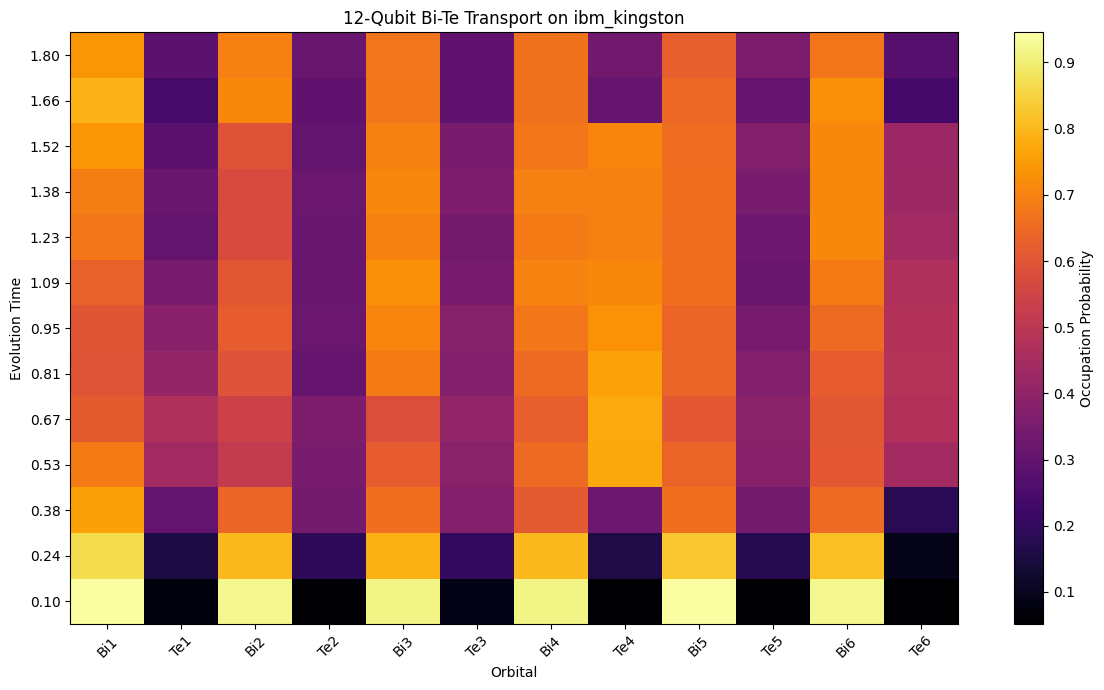

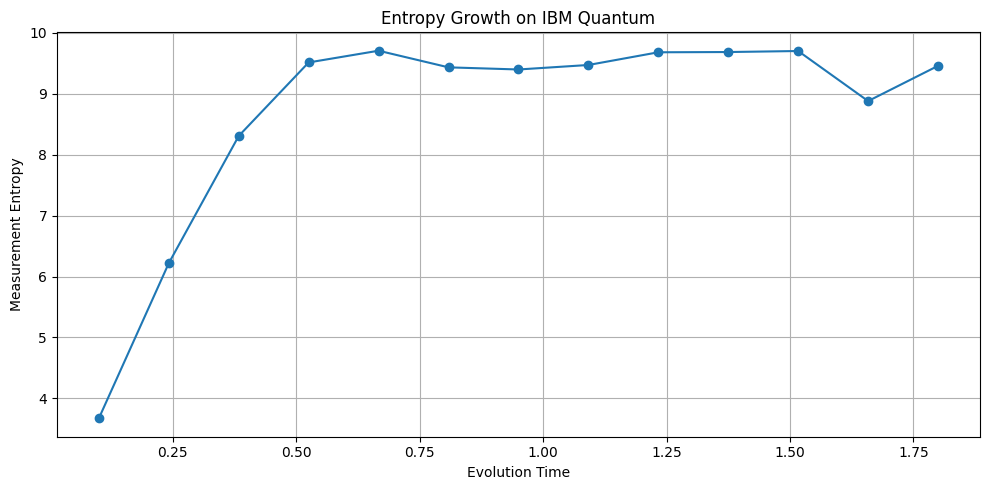


Time | Entropy
-------------------------
 0.10 |   3.6731
 0.24 |   6.2190
 0.38 |   8.3066
 0.53 |   9.5130
 0.67 |   9.7056
 0.81 |   9.4327
 0.95 |   9.3976
 1.09 |   9.4713
 1.23 |   9.6799
 1.38 |   9.6838
 1.52 |   9.7006
 1.66 |   8.8794
 1.80 |   9.4572


In [60]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import (
    generate_preset_pass_manager
)

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

# ============================================================
# IBM ACCOUNT
# ============================================================

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="lO9yQLLS6A6Du3Rlmy-6ydX16QAYT1f_dFTJG_yyXaTA",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a7eb67eae4144c2997ece80128599c24:be6c1e44-ca2c-4d06-b225-d83fe7d5220a::"
)

backend = service.least_busy(operational=True, simulator=False)


print("Backend:", backend.name)

# ============================================================
# MODEL
# ============================================================

N = 12

J = 0.8
HOP = 0.6

times = np.linspace(
    0.1,
    1.8,
    13
)

shots = 4000

# ============================================================
# BUILD CIRCUIT
# ============================================================

def build_circuit(t):

    qc = QuantumCircuit(N)

    #
    # Initial Bi-Te occupation:
    #
    # 101010101010
    #

    for q in range(0, N, 2):
        qc.x(q)

    #
    # Trotter evolution
    #

    trotter_steps = max(
        1,
        int(5 * t)
    )

    dt = t / trotter_steps

    for _ in range(trotter_steps):

        #
        # XX + YY hopping
        #

        for q in range(N - 1):

            qc.rxx(
                2 * HOP * dt,
                q,
                q + 1
            )

            qc.ryy(
                2 * HOP * dt,
                q,
                q + 1
            )

        #
        # Bi/Te onsite energies
        #

        for q in range(N):

            onsite = (
                0.5
                if q % 2 == 0
                else -0.5
            )

            qc.rz(
                2 * onsite * dt,
                q
            )

        #
        # weak interaction
        #

        for q in range(N - 1):

            qc.rzz(
                2 * J * dt,
                q,
                q + 1
            )

    qc.measure_all()

    return qc

# ============================================================
# BUILD CIRCUITS
# ============================================================

circuits = [
    build_circuit(t)
    for t in times
]

# ============================================================
# TRANSPILE
# ============================================================

print("Transpiling...")

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3
)

isa_circuits = [
    pm.run(c)
    for c in circuits
]

print("Done.")

# ============================================================
# RUN
# ============================================================

sampler = Sampler(
    mode=backend
)

sampler.options.default_shots = shots

job = sampler.run(
    isa_circuits
)

print("Job ID:")
print(job.job_id())

result = job.result()

print("Complete.")

# ============================================================
# OCCUPATION MAP
# ============================================================

occupation = np.zeros(
    (
        len(times),
        N
    )
)

for t_idx in range(len(times)):

    counts = (
        result[t_idx]
        .data
        .meas
        .get_counts()
    )

    total = sum(
        counts.values()
    )

    for bitstring, freq in counts.items():

        bits = bitstring[::-1]

        for q, bit in enumerate(bits):

            if bit == "1":

                occupation[
                    t_idx,
                    q
                ] += freq

    occupation[t_idx] /= total

# ============================================================
# ENTROPY
# ============================================================

entropy = []

for t_idx in range(len(times)):

    counts = (
        result[t_idx]
        .data
        .meas
        .get_counts()
    )

    total = sum(
        counts.values()
    )

    s = 0

    for c in counts.values():

        p = c / total

        if p > 0:

            s -= p * np.log2(p)

    entropy.append(s)

# ============================================================
# HEAT MAP
# ============================================================

labels = []

for q in range(N):

    if q % 2 == 0:
        labels.append(
            f"Bi{q//2+1}"
        )
    else:
        labels.append(
            f"Te{q//2+1}"
        )

plt.figure(
    figsize=(12,7)
)

plt.imshow(
    occupation,
    aspect="auto",
    origin="lower",
    cmap="inferno"
)

plt.colorbar(
    label="Occupation Probability"
)

plt.xticks(
    range(N),
    labels,
    rotation=45
)

plt.yticks(
    range(len(times)),
    [
        f"{t:.2f}"
        for t in times
    ]
)

plt.xlabel(
    "Orbital"
)

plt.ylabel(
    "Evolution Time"
)

plt.title(
    f"12-Qubit Bi-Te Transport on {backend.name}"
)

plt.tight_layout()

plt.show()

# ============================================================
# ENTROPY PLOT
# ============================================================

plt.figure(
    figsize=(10,5)
)

plt.plot(
    times,
    entropy,
    marker="o"
)

plt.xlabel(
    "Evolution Time"
)

plt.ylabel(
    "Measurement Entropy"
)

plt.title(
    "Entropy Growth on IBM Quantum"
)

plt.grid(True)

plt.tight_layout()

plt.show()

# ============================================================
# PRINT DATA
# ============================================================

print()
print("Time | Entropy")
print("-" * 25)

for t, s in zip(
    times,
    entropy
):

    print(
        f"{t:5.2f} | {s:8.4f}"
    )

qiskit_runtime_service._discover_account:WARNING:2026-09-15 00:45:30,973: Loading account with the given token. A saved account will not be used.


Backend: ibm_fez

JOB ID
dak9ac9hvn6c73cvat2g
Complete.


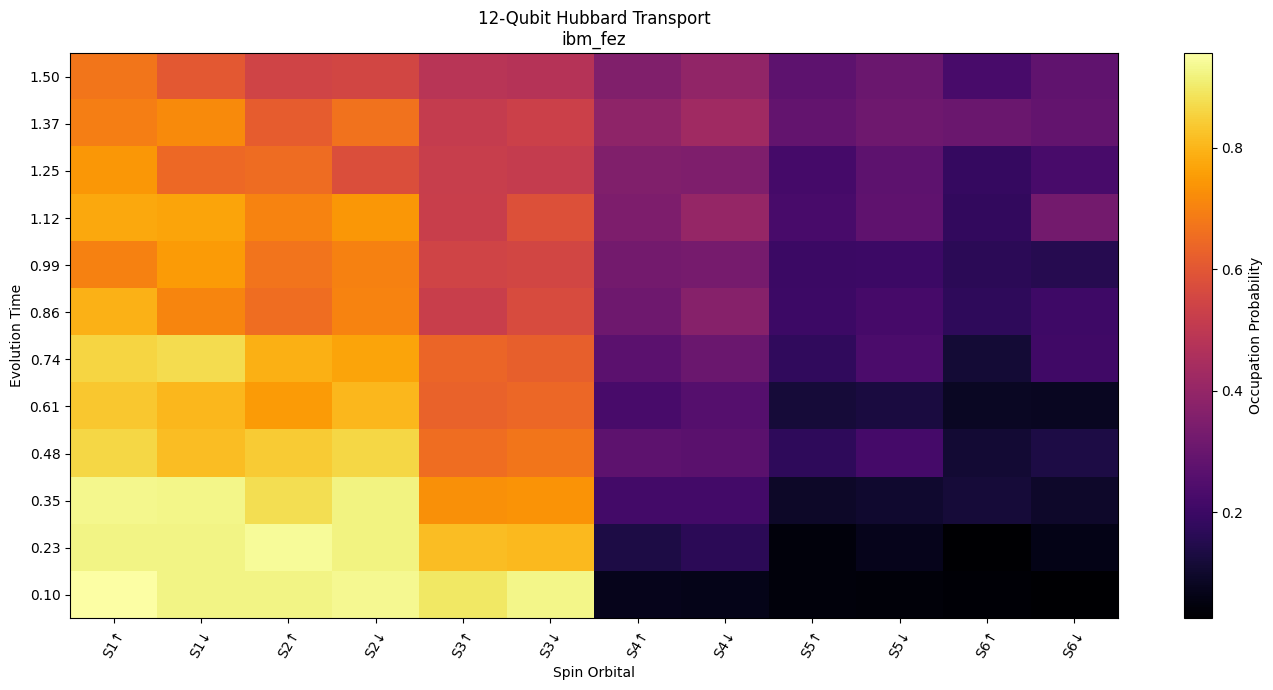

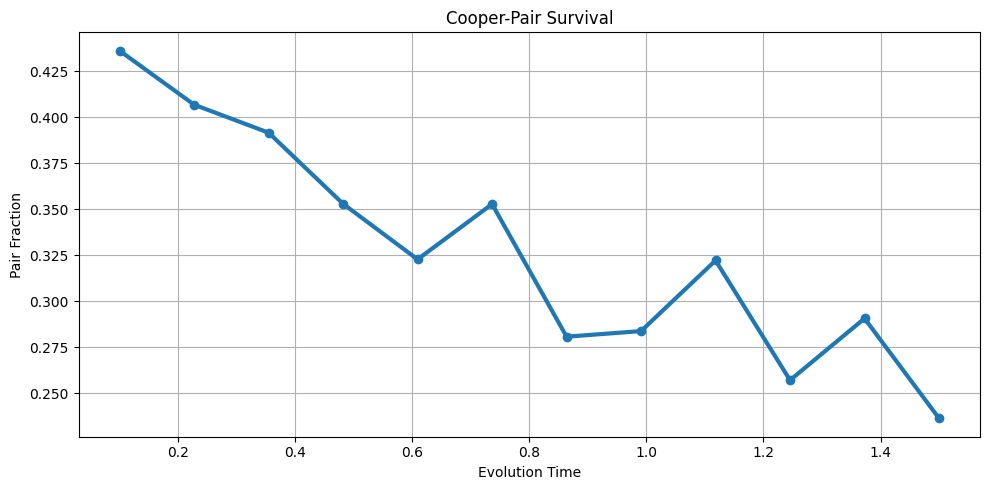

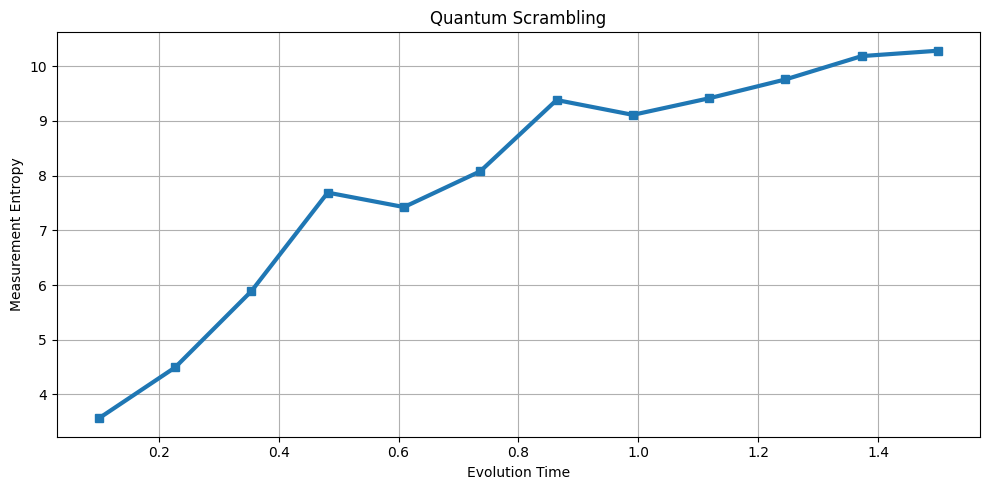


Time | Pair Fraction | Entropy
------------------------------------
0.10 |       0.4362 |   3.5629
0.23 |       0.4068 |   4.4941
0.35 |       0.3916 |   5.8883
0.48 |       0.3529 |   7.6890
0.61 |       0.3227 |   7.4245
0.74 |       0.3528 |   8.0792
0.86 |       0.2807 |   9.3815
0.99 |       0.2837 |   9.1100
1.12 |       0.3221 |   9.4136
1.25 |       0.2570 |   9.7577
1.37 |       0.2906 |  10.1843
1.50 |       0.2362 |  10.2826


In [61]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit

from qiskit.transpiler.preset_passmanagers import (
    generate_preset_pass_manager
)

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

# ==========================================================
# IBM QUANTUM
# ==========================================================


service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="lO9yQLLS6A6Du3Rlmy-6ydX16QAYT1f_dFTJG_yyXaTA",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a7eb67eae4144c2997ece80128599c24:be6c1e44-ca2c-4d06-b225-d83fe7d5220a::"
)

backend = service.least_busy(operational=True, simulator=False)

print("Backend:", backend.name)

# ==========================================================
# HUBBARD PARAMETERS
# ==========================================================

N_SITES = 6

N_QUBITS = 12

#
# hopping strength
#

t_hop = 0.8

#
# attractive interaction
#
# U < 0 favors pairing
#

U = -1.5

times = np.linspace(
    0.1,
    1.5,
    12
)

shots = 4000

# ==========================================================
# PAIRED INITIAL STATE
# ==========================================================
#
# Site1 pair
# Site2 pair
# Site3 pair
#
# 111111000000
#
# ==========================================================

def build_circuit(time):

    qc = QuantumCircuit(N_QUBITS)

    #
    # prepare pairs
    #

    for q in range(6):
        qc.x(q)

    trotter_steps = max(
        1,
        int(8 * time)
    )

    dt = time / trotter_steps

    for _ in range(trotter_steps):

        # --------------------------------------
        # hopping
        # --------------------------------------

        for site in range(N_SITES - 1):

            up_a = 2 * site
            up_b = 2 * (site + 1)

            dn_a = up_a + 1
            dn_b = up_b + 1

            qc.rxx(
                2 * t_hop * dt,
                up_a,
                up_b
            )

            qc.ryy(
                2 * t_hop * dt,
                up_a,
                up_b
            )

            qc.rxx(
                2 * t_hop * dt,
                dn_a,
                dn_b
            )

            qc.ryy(
                2 * t_hop * dt,
                dn_a,
                dn_b
            )

        # --------------------------------------
        # attractive interaction
        # --------------------------------------

        for site in range(N_SITES):

            up = 2 * site
            dn = up + 1

            qc.rzz(
                2 * abs(U) * dt,
                up,
                dn
            )

    qc.measure_all()

    return qc

# ==========================================================
# BUILD CIRCUITS
# ==========================================================

circuits = [
    build_circuit(t)
    for t in times
]

# ==========================================================
# TRANSPILE
# ==========================================================

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3
)

isa_circuits = [
    pm.run(c)
    for c in circuits
]

# ==========================================================
# RUN IBM JOB
# ==========================================================

sampler = Sampler(
    mode=backend
)

sampler.options.default_shots = shots

job = sampler.run(
    isa_circuits
)

print()
print("JOB ID")
print(job.job_id())

result = job.result()

print("Complete.")

# ==========================================================
# OCCUPATION HEAT MAP
# ==========================================================

occupation = np.zeros(
    (
        len(times),
        N_QUBITS
    )
)

entropy = []

pair_fraction = []

# ==========================================================
# ANALYSIS
# ==========================================================

for idx in range(len(times)):

    counts = (
        result[idx]
        .data
        .meas
        .get_counts()
    )

    total = sum(
        counts.values()
    )

    # --------------------------------------
    # entropy
    # --------------------------------------

    s = 0

    for c in counts.values():

        p = c / total

        if p > 0:
            s -= p * np.log2(p)

    entropy.append(s)

    # --------------------------------------
    # occupations
    # --------------------------------------

    pair_count = 0

    for bitstring, freq in counts.items():

        bits = bitstring[::-1]

        for q, bit in enumerate(bits):

            if bit == "1":

                occupation[
                    idx,
                    q
                ] += freq

        #
        # count surviving pairs
        #

        local_pairs = 0

        for site in range(N_SITES):

            up = 2 * site
            dn = up + 1

            if (
                bits[up] == "1"
                and
                bits[dn] == "1"
            ):
                local_pairs += 1

        pair_count += (
            local_pairs * freq
        )

    occupation[idx] /= total

    pair_fraction.append(
        pair_count
        /
        (N_SITES * total)
    )

# ==========================================================
# OCCUPATION HEAT MAP
# ==========================================================

labels = []

for site in range(N_SITES):

    labels.append(
        f"S{site+1}↑"
    )

    labels.append(
        f"S{site+1}↓"
    )

plt.figure(
    figsize=(14, 7)
)

plt.imshow(
    occupation,
    aspect="auto",
    cmap="inferno",
    origin="lower"
)

plt.colorbar(
    label="Occupation Probability"
)

plt.xticks(
    range(N_QUBITS),
    labels,
    rotation=60
)

plt.yticks(
    range(len(times)),
    [
        f"{t:.2f}"
        for t in times
    ]
)

plt.xlabel(
    "Spin Orbital"
)

plt.ylabel(
    "Evolution Time"
)

plt.title(
    f"12-Qubit Hubbard Transport\n{backend.name}"
)

plt.tight_layout()

plt.show()

# ==========================================================
# PAIR SURVIVAL
# ==========================================================

plt.figure(
    figsize=(10,5)
)

plt.plot(
    times,
    pair_fraction,
    marker="o",
    linewidth=3
)

plt.xlabel(
    "Evolution Time"
)

plt.ylabel(
    "Pair Fraction"
)

plt.title(
    "Cooper-Pair Survival"
)

plt.grid(True)

plt.tight_layout()

plt.show()

# ==========================================================
# ENTROPY
# ==========================================================

plt.figure(
    figsize=(10,5)
)

plt.plot(
    times,
    entropy,
    marker="s",
    linewidth=3
)

plt.xlabel(
    "Evolution Time"
)

plt.ylabel(
    "Measurement Entropy"
)

plt.title(
    "Quantum Scrambling"
)

plt.grid(True)

plt.tight_layout()

plt.show()

# ==========================================================
# TABLE
# ==========================================================

print()
print(
    "Time | Pair Fraction | Entropy"
)

print("-" * 36)

for t, p, s in zip(
    times,
    pair_fraction,
    entropy
):

    print(
        f"{t:4.2f} | "
        f"{p:12.4f} | "
        f"{s:8.4f}"
    )

In [64]:
import numpy as np
import matplotlib.pyplot as plt

N_SITES = 6

corr_matrix = np.zeros(
    (N_SITES, N_SITES)
)

# use latest time point
counts = (
    result[len(times) - 1]
    .data
    .meas
    .get_counts()
)

total = sum(counts.values())

for bitstring, freq in counts.items():

    bits = bitstring[::-1]

    pair_values = []

    #
    # paired site observable
    #
    # +1 if both match
    # -1 if mixed
    #

    for site in range(N_SITES):

        up = 2 * site
        dn = up + 1

        zu = 1 if bits[up] == "0" else -1
        zd = 1 if bits[dn] == "0" else -1

        pair_values.append(
            zu * zd
        )

    #
    # correlation matrix
    #

    for i in range(N_SITES):

        for j in range(N_SITES):

            corr_matrix[i,j] += (
                pair_values[i]
                *
                pair_values[j]
                *
                freq
            )

corr_matrix /= total


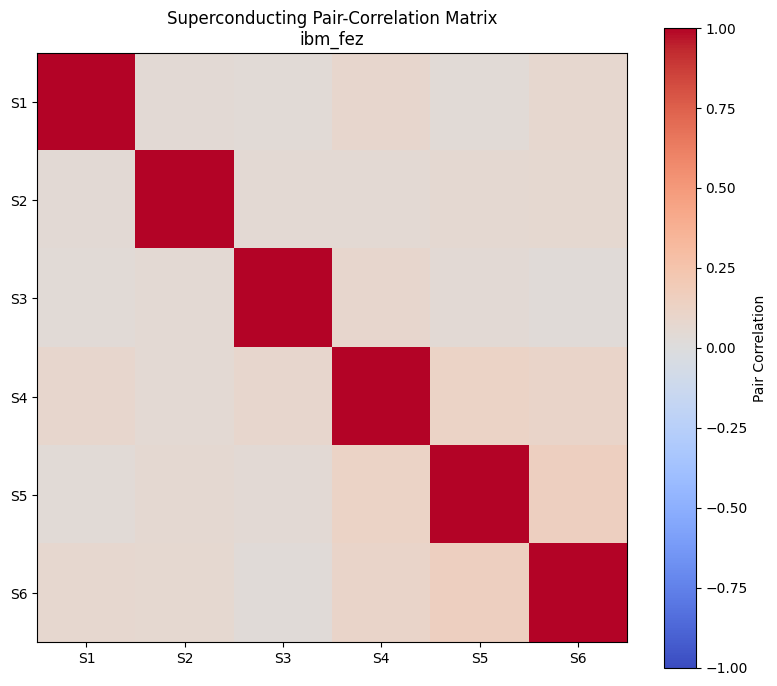

In [65]:
plt.figure(
    figsize=(8,7)
)

plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    label="Pair Correlation"
)

labels = [
    f"S{i+1}"
    for i in range(N_SITES)
]

plt.xticks(
    range(N_SITES),
    labels
)

plt.yticks(
    range(N_SITES),
    labels
)

plt.title(
    f"Superconducting Pair-Correlation Matrix\n{backend.name}"
)

plt.tight_layout()
plt.show()

In [66]:
correlations_vs_time = []

for idx in range(len(times)):

    counts = (
        result[idx]
        .data
        .meas
        .get_counts()
    )

    matrix = np.zeros(
        (N_SITES,N_SITES)
    )

    total = sum(
        counts.values()
    )

    for bitstring,freq in counts.items():

        bits = bitstring[::-1]

        pair_vals = []

        for site in range(N_SITES):

            up = 2*site
            dn = up+1

            zu = 1 if bits[up]=="0" else -1
            zd = 1 if bits[dn]=="0" else -1

            pair_vals.append(
                zu*zd
            )

        for i in range(N_SITES):
            for j in range(N_SITES):

                matrix[i,j] += (
                    pair_vals[i]
                    * pair_vals[j]
                    * freq
                )

    matrix /= total

    correlations_vs_time.append(
        matrix
    )

/tmp/ipykernel_506/4116296918.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


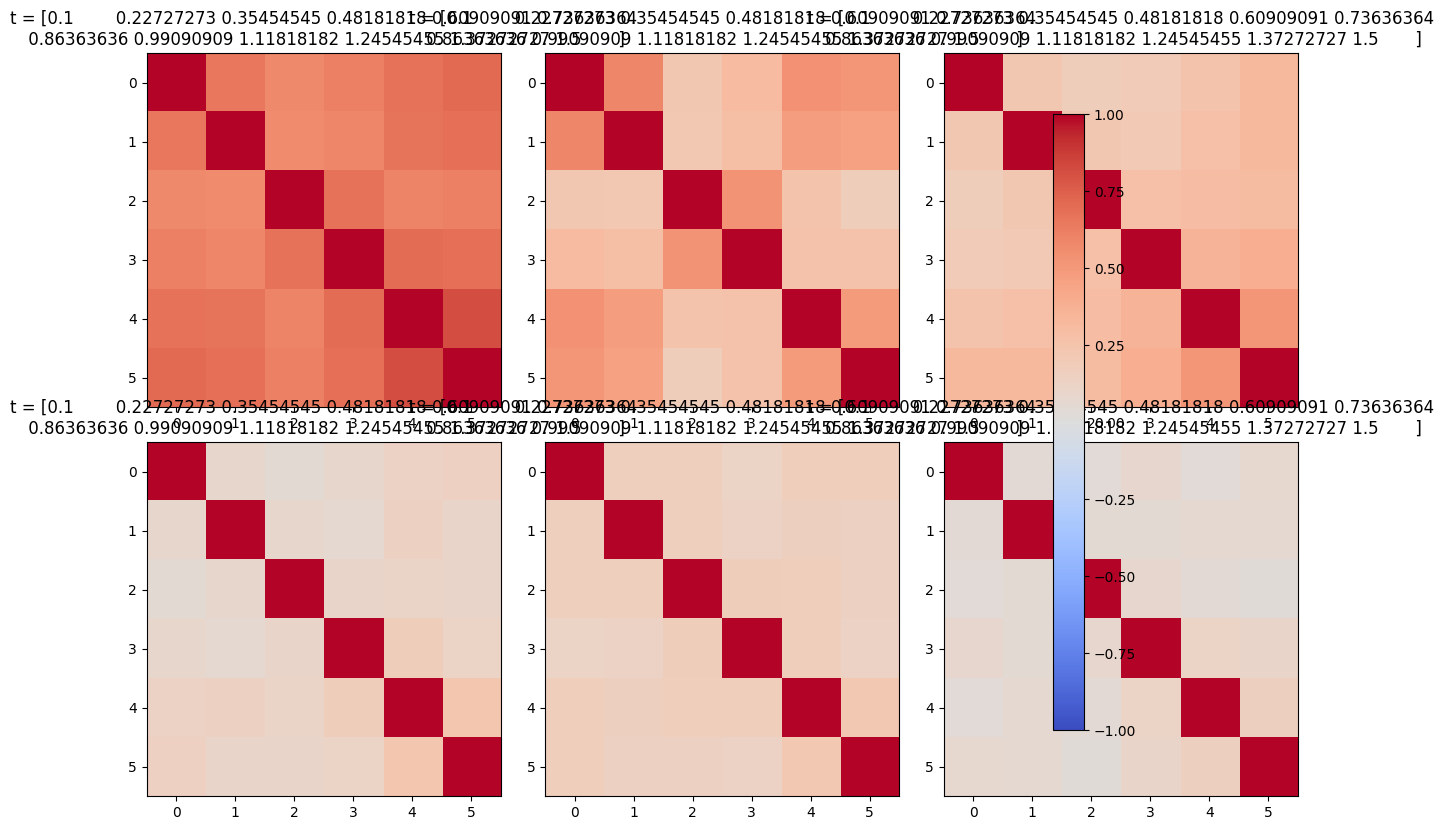

In [72]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(12,8)
)

indices = [
    0,
    2,
    4,
    6,
    8,
    11
]


for ax, idx in zip(
    axes.flat,
    indices
):

    im = ax.imshow(
        correlations_vs_time[idx],
        cmap="coolwarm",
        vmin=-1,
        vmax=1
    )

    ax.set_title(
        f"t = {times}"
    )


fig.colorbar(
    im,
    ax=axes.ravel().tolist()
)

plt.tight_layout()
plt.show()

In [74]:
!pip install qiskit_optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 11.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 10.7 MB/s eta 0:00:00
  Created wheel for docplex: filename=docplex-2.32.264-py3-none-any.whl size=703859 sha256=9f2704938ad828da73fe2a350c96425f38c6c06c79cd5d3615e14548c7c2c185
  Stored in directory: /root/.cache/pip/wheels/ba/11/de/5d0051be010658975fb2155006b4b8a818136d9f69ed20b4ba
Successfully built docplex


In [76]:
# ============================================================
# QISKIT QAOA DEBT OPTIMIZER
# IBM QUANTUM VERSION
# ============================================================

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer

from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA

# ============================================================
# IBM ACCOUNT
# ============================================================

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="lO9yQLLS6A6Du3Rlmy-6ydX16QAYT1f_dFTJG_yyXaTA",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a7eb67eae4144c2997ece80128599c24:be6c1e44-ca2c-4d06-b225-d83fe7d5220a::"
)

backend = service.least_busy(operational=True, simulator=False)

print("Backend:", backend.name)

# ============================================================
# SAMPLE DEBTS
# ============================================================

debts = [
    ("CreditCard", 20000, 24.0),
    ("PersonalLoan", 15000, 14.0),
    ("AutoLoan", 35000, 6.0)
]

# ============================================================
# QUBO FORMULATION
# ============================================================

qp = QuadraticProgram()

for name, balance, apr in debts:

    qp.binary_var(name=name)

# maximize APR-weighted payoff priority
# converted into minimization

qp.minimize(
    linear={
        name: -(apr * balance)
        for name, balance, apr in debts
    }
)

# choose exactly one focus debt

qp.linear_constraint(
    linear={
        name: 1
        for name, _, _ in debts
    },
    sense="==",
    rhs=1,
    name="choose_one"
)

# ============================================================
# QAOA
# ============================================================

sampler = Sampler(mode=backend)

qaoa = QAOA(
    sampler=sampler,
    optimizer=COBYLA(maxiter=100),
    reps=2
)

optimizer = MinimumEigenOptimizer(
    qaoa
)

result = optimizer.solve(qp)

# ============================================================
# RESULTS
# ============================================================

print()
print("Optimal Priority Debt")
print("----------------------")

for var, value in result.variables_dict.items():

    if value > 0.5:

        print(var)

print()
print("Objective Value")
print(result.fval)

qiskit_runtime_service._discover_account:WARNING:2026-09-15 00:55:59,757: Loading account with the given token. A saved account will not be used.


Backend: ibm_kingston


IBMInputValueError: 'The instruction QAOA on qubits (0, 1, 2) is not supported by the target system. Circuits that do not match the target hardware definition are no longer supported after March 4, 2024. See the transpilation documentation (https://quantum.cloud.ibm.com/docs/guides/transpile) for instructions to transform circuits and the primitive examples (https://quantum.cloud.ibm.com/docs/guides/primitives-examples) to see this coupled with operator transformations.'

In [78]:
# =====================================================
# QUANTUM SIDE HUSTLE OPTIMIZER
# IBM QUANTUM + QAOA
# =====================================================

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import (
    MinimumEigenOptimizer
)

from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA

# =====================================================
# IBM ACCOUNT
# =====================================================

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="lO9yQLLS6A6Du3Rlmy-6ydX16QAYT1f_dFTJG_yyXaTA",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a7eb67eae4144c2997ece80128599c24:be6c1e44-ca2c-4d06-b225-d83fe7d5220a::"
)

backend = service.least_busy(operational=True, simulator=False)

print("Backend:", backend.name)


# =====================================================
# SIDE HUSTLES
# =====================================================
#
# income
# startup cost
# hours/week
# skill match
# scalability
#
# score =
# income
# - cost
# - time
# + skill
# + scalability
#
# =====================================================

hustles = {
    "AI_Consulting":      [10, 2, 3, 10, 10],
    "PowerPoint_Design":  [8, 1, 4, 10, 7],
    "Dashboard_Design":   [8, 1, 4, 9, 7],
    "YouTube":            [7, 2, 6, 7, 10],
    "Etsy_Templates":     [6, 1, 3, 8, 9],
    "Online_Course":      [8, 2, 5, 8, 9],
    "App_SaaS":          [10, 5, 8, 7, 10],
    "Freelancing":        [9, 1, 4, 9, 6]
}

# =====================================================
# BUILD QUBO
# =====================================================

qp = QuadraticProgram()

for hustle in hustles:
    qp.binary_var(name=hustle)

linear = {}

for name, vals in hustles.items():

    income = vals[0]
    cost = vals[1]
    time = vals[2]
    skill = vals[3]
    scale = vals[4]

    score = (
        income
        - cost
        - time
        + skill
        + scale
    )

    linear[name] = -score

qp.minimize(linear=linear)

# =====================================================
# CONSTRAINT
# Choose up to 3 hustles
# =====================================================

qp.linear_constraint(
    linear={
        h: 1
        for h in hustles
    },
    sense="<=",
    rhs=3,
    name="choose_three"
)

# =====================================================
# QAOA
# =====================================================

sampler = Sampler(mode=backend)

qaoa = QAOA(
    sampler=sampler,
    optimizer=COBYLA(maxiter=100),
    reps=2
)

optimizer = MinimumEigenOptimizer(qaoa)

print("\nRunning quantum optimization...")

result = optimizer.solve(qp)

# =====================================================
# RESULTS
# =====================================================

print("\n==========================")
print("QUANTUM SIDE HUSTLE PICKS")
print("==========================")

selected = []

for name, value in result.variables_dict.items():

    if value > 0.5:

        selected.append(name)

        print("✓", name)

print()

print("Objective Value:")
print(result.fval)

# =====================================================
# PROJECTED SCORE
# =====================================================

print("\nDETAILS")

for hustle in selected:

    income, cost, time, skill, scale = hustles[hustle]

    print(
        f"\n{hustle}"
    )

    print(
        f" Income       : {income}"
    )

    print(
        f" Startup Cost : {cost}"
    )

    print(
        f" Hours/Week   : {time}"
    )

    print(
        f" Skill Match  : {skill}"
    )

    print(
        f" Scalability  : {scale}"
    )

qiskit_runtime_service._discover_account:WARNING:2026-09-15 00:58:27,937: Loading account with the given token. A saved account will not be used.


Backend: ibm_fez

Running quantum optimization...


IBMInputValueError: 'The instruction QAOA on qubits (0, 1, 2, 3, 4, 5, 6, 7, 8, 9) is not supported by the target system. Circuits that do not match the target hardware definition are no longer supported after March 4, 2024. See the transpilation documentation (https://quantum.cloud.ibm.com/docs/guides/transpile) for instructions to transform circuits and the primitive examples (https://quantum.cloud.ibm.com/docs/guides/primitives-examples) to see this coupled with operator transformations.'

In [79]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import (
    generate_preset_pass_manager
)

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

# ============================================================
# IBM LOGIN
# ============================================================

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="lO9yQLLS6A6Du3Rlmy-6ydX16QAYT1f_dFTJG_yyXaTA",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a7eb67eae4144c2997ece80128599c24:be6c1e44-ca2c-4d06-b225-d83fe7d5220a::"
)

backend = service.least_busy(operational=True, simulator=False)

print("Backend:", backend.name)

# ============================================================
# SIDE HUSTLES
# ============================================================

hustles = [
    "AI Consulting",
    "PowerPoint Design",
    "Dashboard Design",
    "YouTube",
    "Etsy Templates",
    "Online Course",
    "SaaS App",
    "Freelancing"
]

# score = income - time - cost + scalability

scores = np.array([
    25,
    20,
    19,
    14,
    16,
    18,
    23,
    21
])

n = len(hustles)

# ============================================================
# QAOA-LIKE CIRCUIT
# ============================================================

gamma = 0.7
beta = 0.8

qc = QuantumCircuit(n)

# uniform superposition

for q in range(n):
    qc.h(q)

# cost operator

for q in range(n):

    angle = gamma * scores[q] / 10

    qc.rz(angle, q)

# mixing operator

for q in range(n):
    qc.rx(2 * beta, q)

qc.measure_all()

# ============================================================
# TRANSPILE
# ============================================================

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3
)

isa_qc = pm.run(qc)

# ============================================================
# RUN
# ============================================================

sampler = Sampler(mode=backend)

sampler.options.default_shots = 10000

job = sampler.run([isa_qc])

print()
print("Job ID:")
print(job.job_id())

result = job.result()

# ============================================================
# ANALYZE
# ============================================================

counts = result[0].data.meas.get_counts()

best_string = max(
    counts,
    key=counts.get
)

print()
print("Winning Bitstring:")
print(best_string)

print()
print("Recommended Hustles")

bits = best_string[::-1]

for i, bit in enumerate(bits):

    if bit == "1":

        print(
            "✓",
            hustles[i]
        )

# ============================================================
# RANKINGS
# ============================================================

print()
print("Raw Scores")

for name, score in zip(
    hustles,
    scores
):
    print(
        f"{name:20s} {score}"
    )

qiskit_runtime_service._discover_account:WARNING:2026-09-15 00:58:35,038: Loading account with the given token. A saved account will not be used.


Backend: ibm_fez

Job ID:
dak9ggj9k43c73ai4re0

Winning Bitstring:
00000000

Recommended Hustles

Raw Scores
AI Consulting        25
PowerPoint Design    20
Dashboard Design     19
YouTube              14
Etsy Templates       16
Online Course        18
SaaS App             23
Freelancing          21


In [8]:
import math
from collections import Counter

import numpy as np

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import (
    generate_preset_pass_manager
)

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)


# ============================================================
# CONFIGURATION
# ============================================================

WHITE_MAX = 69
WHITE_COUNT = 5

POWERBALL_MAX = 26

SHOTS = 10000

# Number of lottery tickets we want to construct
NUM_TICKETS = 20


# ============================================================
# IBM QUANTUM LOGIN
# ============================================================
#
# IMPORTANT:
# Do NOT paste your API token directly into this script.
#
# If your IBM account is already saved:
#
#     service = QiskitRuntimeService()
#
# Otherwise save it once with:
#
# QiskitRuntimeService.save_account(
#     channel="ibm_quantum_platform",
#     token="YOUR_NEW_TOKEN",
#     overwrite=True
# )
#
# Then this program can simply use:
#
#     service = QiskitRuntimeService()
#
# ============================================================



service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="lO9yQLLS6A6Du3Rlmy-6ydX16QAYT1f_dFTJG_yyXaTA",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a7eb67eae4144c2997ece80128599c24:be6c1e44-ca2c-4d06-b225-d83fe7d5220a::"
)

backend = service.least_busy(operational=True, simulator=False)
# ============================================================
# SELECT IBM HARDWARE
# ============================================================


print("=" * 70)
print("QUANTUM LOTTERY EXPERIMENT")
print("=" * 70)

print()
print("Backend:", backend.name)
print("Qubits:", backend.num_qubits)


# ============================================================
# QUANTUM RANDOMNESS CIRCUIT
# ============================================================
#
# We need enough random bits to construct numbers.
#
# 6 bits gives:
#
#     0 - 63
#
# which is insufficient for 1-69.
#
# Therefore we use 7 bits:
#
#     0 - 127
#
# and reject values > 68.
#
# This is rejection sampling.
#
# ============================================================

NUM_BITS = 7


def create_random_circuit():

    qc = QuantumCircuit(NUM_BITS)

    # Put every qubit into an equal superposition.
    for q in range(NUM_BITS):
        qc.h(q)

    qc.measure_all()

    return qc


qc = create_random_circuit()


# ============================================================
# TRANSPILE
# ============================================================

print()
print("Transpiling circuit...")

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3
)

isa_qc = pm.run(qc)


# ============================================================
# RUN ON REAL IBM HARDWARE
# ============================================================

print()
print("Submitting quantum circuit...")
print("Shots:", SHOTS)

sampler = Sampler(mode=backend)

sampler.options.default_shots = SHOTS

job = sampler.run([isa_qc])

print()
print("Job ID:")
print(job.job_id())


# ============================================================
# WAIT FOR RESULT
# ============================================================

print()
print("Waiting for quantum hardware result...")

result = job.result()

counts = result[0].data.meas.get_counts()

print()
print("Quantum measurement states:", len(counts))


# ============================================================
# DISPLAY RAW QUANTUM DISTRIBUTION
# ============================================================

print()
print("=" * 70)
print("RAW QUANTUM MEASUREMENTS")
print("=" * 70)

sorted_counts = sorted(
    counts.items(),
    key=lambda x: x[1],
    reverse=True
)

for bitstring, count in sorted_counts[:20]:

    print(
        f"{bitstring} : {count}"
    )


# ============================================================
# CONVERT COUNTS INTO A RANDOM BIT STREAM
# ============================================================
#
# We expand the measurement histogram into individual
# observations.
#
# ============================================================

raw_values = []

for bitstring, count in counts.items():

    value = int(
        bitstring,
        2
    )

    for _ in range(count):

        raw_values.append(value)


# ============================================================
# SHUFFLE
# ============================================================
#
# This is ONLY to prevent histogram ordering from influencing
# ticket construction.
#
# The actual entropy comes from the quantum measurement.
#
# ============================================================

rng = np.random.default_rng()

rng.shuffle(raw_values)


# ============================================================
# QUANTUM INTEGER GENERATOR
# ============================================================

index = 0


def quantum_number(max_value):

    """
    Generate an integer from 1..max_value
    using quantum measurement results.

    Rejection sampling avoids modulo bias.
    """

    global index

    while True:

        if index >= len(raw_values):

            raise RuntimeError(
                "Not enough quantum measurements."
            )

        value = raw_values[index]

        index += 1

        # 7-bit values are 0..127.
        #
        # For max_value=69:
        #
        # acceptable range:
        # 0..68
        #
        # We reject everything outside that range.
        #
        limit = (
            (128 // max_value)
            * max_value
        )

        if value >= limit:
            continue

        return (
            value % max_value
        ) + 1


# ============================================================
# GENERATE ONE POWERBALL TICKET
# ============================================================

def generate_ticket():

    white_numbers = set()

    while len(white_numbers) < WHITE_COUNT:

        number = quantum_number(
            WHITE_MAX
        )

        white_numbers.add(number)

    white_numbers = sorted(
        white_numbers
    )

    powerball = quantum_number(
        POWERBALL_MAX
    )

    return (
        white_numbers,
        powerball
    )


# ============================================================
# GENERATE TICKETS
# ============================================================

tickets = []

for _ in range(NUM_TICKETS):

    ticket = generate_ticket()

    tickets.append(ticket)


# ============================================================
# DISPLAY TICKETS
# ============================================================

print()
print("=" * 70)
print("QUANTUM-GENERATED LOTTERY TICKETS")
print("=" * 70)

for i, (white, powerball) in enumerate(
    tickets,
    start=1
):

    white_string = " ".join(
        f"{x:02d}"
        for x in white
    )

    print(
        f"{i:02d}: "
        f"{white_string} "
        f"| PB {powerball:02d}"
    )


# ============================================================
# NUMBER FREQUENCIES
# ============================================================

white_frequency = Counter()
powerball_frequency = Counter()

for white, powerball in tickets:

    for number in white:

        white_frequency[number] += 1

    powerball_frequency[
        powerball
    ] += 1


# ============================================================
# WHITE BALL FREQUENCY
# ============================================================

print()
print("=" * 70)
print("WHITE-BALL FREQUENCY")
print("=" * 70)

for number, frequency in sorted(
    white_frequency.items(),
    key=lambda x: x[1],
    reverse=True
):

    print(
        f"{number:02d} : {frequency}"
    )


# ============================================================
# POWERBALL FREQUENCY
# ============================================================

print()
print("=" * 70)
print("POWERBALL FREQUENCY")
print("=" * 70)

for number, frequency in sorted(
    powerball_frequency.items(),
    key=lambda x: x[1],
    reverse=True
):

    print(
        f"{number:02d} : {frequency}"
    )


# ============================================================
# MOST FREQUENT NUMBERS
# ============================================================

top_white = [
    number
    for number, _ in white_frequency.most_common(
        WHITE_COUNT
    )
]

top_white.sort()

top_powerball = (
    powerball_frequency
    .most_common(1)[0][0]
)


print()
print("=" * 70)
print("MOST FREQUENT QUANTUM NUMBERS")
print("=" * 70)

print()

print(
    "Top 5 white numbers:",
    " ".join(
        f"{x:02d}"
        for x in top_white
    )
)

print(
    "Top Powerball:",
    f"{top_powerball:02d}"
)


# ============================================================
# ENTROPY
# ============================================================

def shannon_entropy(counter):

    total = sum(
        counter.values()
    )

    entropy = 0.0

    for count in counter.values():

        p = count / total

        entropy -= (
            p * math.log2(p)
        )

    return entropy


white_entropy = shannon_entropy(
    white_frequency
)

powerball_entropy = shannon_entropy(
    powerball_frequency
)


print()
print("=" * 70)
print("ENTROPY")
print("=" * 70)

print(
    f"White-ball entropy: "
    f"{white_entropy:.4f} bits"
)

print(
    f"Powerball entropy: "
    f"{powerball_entropy:.4f} bits"
)


# ============================================================
# IMPORTANT INTERPRETATION
# ============================================================

print()
print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print()
print(
    "These numbers are quantum-generated random candidates."
)

print(
    "The most frequent numbers are NOT predicted winning numbers."
)

print(
    "A properly conducted lottery should be unpredictable."
)

print(
    "The purpose of this experiment is to test quantum"
)

print(
    "randomness and generate lottery candidates."
)

print()
print("=" * 70)
print("EXPERIMENT COMPLETE")
print("=" * 70)

qiskit_runtime_service._discover_account:WARNING:2026-09-15 17:28:16,343: Loading account with the given token. A saved account will not be used.


QUANTUM LOTTERY EXPERIMENT

Backend: ibm_kingston
Qubits: 156

Transpiling circuit...

Submitting quantum circuit...
Shots: 10000

Job ID:
dako0dot9ckc739kglv0

Waiting for quantum hardware result...


KeyboardInterrupt: 

In [7]:
import math
from collections import Counter

import numpy as np

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import (
    generate_preset_pass_manager
)

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)


# ============================================================
# CONFIGURATION
# ============================================================

WHITE_MAX = 69
WHITE_COUNT = 5

POWERBALL_MAX = 26

SHOTS = 10000

# Number of lottery tickets we want to construct
NUM_TICKETS = 20


# ============================================================
# IBM QUANTUM LOGIN
# ============================================================
#
# IMPORTANT:
# Do NOT paste your API token directly into this script.
#
# If your IBM account is already saved:
#
#     service = QiskitRuntimeService()
#
# Otherwise save it once with:
#
# QiskitRuntimeService.save_account(
#     channel="ibm_quantum_platform",
#     token="YOUR_NEW_TOKEN",
#     overwrite=True
# )
#
# Then this program can simply use:
#
#     service = QiskitRuntimeService()
#
# ============================================================



service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="lO9yQLLS6A6Du3Rlmy-6ydX16QAYT1f_dFTJG_yyXaTA",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a7eb67eae4144c2997ece80128599c24:be6c1e44-ca2c-4d06-b225-d83fe7d5220a::"
)

backend = service.least_busy(operational=True, simulator=False)
# ============================================================
# SELECT IBM HARDWARE
# ============================================================


print("=" * 70)
print("QUANTUM LOTTERY EXPERIMENT")
print("=" * 70)

print()
print("Backend:", backend.name)
print("Qubits:", backend.num_qubits)


# ============================================================
# QUANTUM RANDOMNESS CIRCUIT
# ============================================================
#
# We need enough random bits to construct numbers.
#
# 6 bits gives:
#
#     0 - 63
#
# which is insufficient for 1-69.
#
# Therefore we use 7 bits:
#
#     0 - 127
#
# and reject values > 68.
#
# This is rejection sampling.
#
# ============================================================

NUM_BITS = 7


def create_random_circuit():

    qc = QuantumCircuit(NUM_BITS)

    # Put every qubit into an equal superposition.
    for q in range(NUM_BITS):
        qc.h(q)

    qc.measure_all()

    return qc


qc = create_random_circuit()


# ============================================================
# TRANSPILE
# ============================================================

print()
print("Transpiling circuit...")

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3
)

isa_qc = pm.run(qc)


# ============================================================
# RUN ON REAL IBM HARDWARE
# ============================================================

print()
print("Submitting quantum circuit...")
print("Shots:", SHOTS)

sampler = Sampler(mode=backend)

sampler.options.default_shots = SHOTS

job = sampler.run([isa_qc])

print()
print("Job ID:")
print(job.job_id())


# ============================================================
# WAIT FOR RESULT
# ============================================================

print()
print("Waiting for quantum hardware result...")

result = job.result()

counts = result[0].data.meas.get_counts()

print()
print("Quantum measurement states:", len(counts))


# ============================================================
# DISPLAY RAW QUANTUM DISTRIBUTION
# ============================================================

print()
print("=" * 70)
print("RAW QUANTUM MEASUREMENTS")
print("=" * 70)

sorted_counts = sorted(
    counts.items(),
    key=lambda x: x[1],
    reverse=True
)

for bitstring, count in sorted_counts[:20]:

    print(
        f"{bitstring} : {count}"
    )


# ============================================================
# CONVERT COUNTS INTO A RANDOM BIT STREAM
# ============================================================
#
# We expand the measurement histogram into individual
# observations.
#
# ============================================================

raw_values = []

for bitstring, count in counts.items():

    value = int(
        bitstring,
        2
    )

    for _ in range(count):

        raw_values.append(value)


# ============================================================
# SHUFFLE
# ============================================================
#
# This is ONLY to prevent histogram ordering from influencing
# ticket construction.
#
# The actual entropy comes from the quantum measurement.
#
# ============================================================

rng = np.random.default_rng()

rng.shuffle(raw_values)


# ============================================================
# QUANTUM INTEGER GENERATOR
# ============================================================

index = 0


def quantum_number(max_value):

    """
    Generate an integer from 1..max_value
    using quantum measurement results.

    Rejection sampling avoids modulo bias.
    """

    global index

    while True:

        if index >= len(raw_values):

            raise RuntimeError(
                "Not enough quantum measurements."
            )

        value = raw_values[index]

        index += 1

        # 7-bit values are 0..127.
        #
        # For max_value=69:
        #
        # acceptable range:
        # 0..68
        #
        # We reject everything outside that range.
        #
        limit = (
            (128 // max_value)
            * max_value
        )

        if value >= limit:
            continue

        return (
            value % max_value
        ) + 1


# ============================================================
# GENERATE ONE POWERBALL TICKET
# ============================================================

def generate_ticket():

    white_numbers = set()

    while len(white_numbers) < WHITE_COUNT:

        number = quantum_number(
            WHITE_MAX
        )

        white_numbers.add(number)

    white_numbers = sorted(
        white_numbers
    )

    powerball = quantum_number(
        POWERBALL_MAX
    )

    return (
        white_numbers,
        powerball
    )


# ============================================================
# GENERATE TICKETS
# ============================================================

tickets = []

for _ in range(NUM_TICKETS):

    ticket = generate_ticket()

    tickets.append(ticket)


# ============================================================
# DISPLAY TICKETS
# ============================================================

print()
print("=" * 70)
print("QUANTUM-GENERATED LOTTERY TICKETS")
print("=" * 70)

for i, (white, powerball) in enumerate(
    tickets,
    start=1
):

    white_string = " ".join(
        f"{x:02d}"
        for x in white
    )

    print(
        f"{i:02d}: "
        f"{white_string} "
        f"| PB {powerball:02d}"
    )


# ============================================================
# NUMBER FREQUENCIES
# ============================================================

white_frequency = Counter()
powerball_frequency = Counter()

for white, powerball in tickets:

    for number in white:

        white_frequency[number] += 1

    powerball_frequency[
        powerball
    ] += 1


# ============================================================
# WHITE BALL FREQUENCY
# ============================================================

print()
print("=" * 70)
print("WHITE-BALL FREQUENCY")
print("=" * 70)

for number, frequency in sorted(
    white_frequency.items(),
    key=lambda x: x[1],
    reverse=True
):

    print(
        f"{number:02d} : {frequency}"
    )


# ============================================================
# POWERBALL FREQUENCY
# ============================================================

print()
print("=" * 70)
print("POWERBALL FREQUENCY")
print("=" * 70)

for number, frequency in sorted(
    powerball_frequency.items(),
    key=lambda x: x[1],
    reverse=True
):

    print(
        f"{number:02d} : {frequency}"
    )


# ============================================================
# MOST FREQUENT NUMBERS
# ============================================================

top_white = [
    number
    for number, _ in white_frequency.most_common(
        WHITE_COUNT
    )
]

top_white.sort()

top_powerball = (
    powerball_frequency
    .most_common(1)[0][0]
)


print()
print("=" * 70)
print("MOST FREQUENT QUANTUM NUMBERS")
print("=" * 70)

print()

print(
    "Top 5 white numbers:",
    " ".join(
        f"{x:02d}"
        for x in top_white
    )
)

print(
    "Top Powerball:",
    f"{top_powerball:02d}"
)


# ============================================================
# ENTROPY
# ============================================================

def shannon_entropy(counter):

    total = sum(
        counter.values()
    )

    entropy = 0.0

    for count in counter.values():

        p = count / total

        entropy -= (
            p * math.log2(p)
        )

    return entropy


white_entropy = shannon_entropy(
    white_frequency
)

powerball_entropy = shannon_entropy(
    powerball_frequency
)


print()
print("=" * 70)
print("ENTROPY")
print("=" * 70)

print(
    f"White-ball entropy: "
    f"{white_entropy:.4f} bits"
)

print(
    f"Powerball entropy: "
    f"{powerball_entropy:.4f} bits"
)


# ============================================================
# IMPORTANT INTERPRETATION
# ============================================================

print()
print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print()
print(
    "These numbers are quantum-generated random candidates."
)

print(
    "The most frequent numbers are NOT predicted winning numbers."
)

print(
    "A properly conducted lottery should be unpredictable."
)

print(
    "The purpose of this experiment is to test quantum"
)

print(
    "randomness and generate lottery candidates."
)

print()
print("=" * 70)
print("EXPERIMENT COMPLETE")
print("=" * 70)

qiskit_runtime_service._discover_account:WARNING:2026-09-15 23:59:06,951: Loading account with the given token. A saved account will not be used.


QUANTUM LOTTERY EXPERIMENT

Backend: ibm_kingston
Qubits: 156

Transpiling circuit...

Submitting quantum circuit...
Shots: 10000

Job ID:
daktnkc62pvc739q1qjg

Waiting for quantum hardware result...

Quantum measurement states: 128

RAW QUANTUM MEASUREMENTS
1101010 : 107
0100110 : 106
0010110 : 100
1011110 : 98
0111110 : 98
1100111 : 96
0001100 : 95
1001111 : 95
1001000 : 91
1011011 : 90
0000100 : 89
1111011 : 89
1100110 : 89
0101100 : 89
1111101 : 89
1000010 : 88
0011010 : 88
1111001 : 88
0101101 : 88
0110101 : 87

QUANTUM-GENERATED LOTTERY TICKETS
01: 11 33 40 61 67 | PB 23
02: 11 17 54 59 61 | PB 23
03: 01 21 37 50 65 | PB 03
04: 20 36 42 46 59 | PB 19
05: 13 15 23 35 57 | PB 17
06: 15 24 41 54 67 | PB 12
07: 10 15 21 37 61 | PB 24
08: 14 31 36 59 63 | PB 15
09: 03 12 44 49 66 | PB 13
10: 02 16 36 39 49 | PB 12
11: 06 20 27 54 67 | PB 14
12: 29 30 38 48 57 | PB 13
13: 01 35 55 59 63 | PB 23
14: 07 21 38 49 54 | PB 24
15: 14 35 41 45 61 | PB 24
16: 10 15 40 49 67 | PB 02
17: 02 09 2

In [9]:
import math
import itertools
from collections import Counter

import numpy as np
from scipy import stats

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import (
    generate_preset_pass_manager
)

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)


# ============================================================
# WHAT THIS SCRIPT ACTUALLY DOES -- PLEASE READ FIRST
# ============================================================
#
# This does NOT estimate "the probability we are in a simulation."
# No known physical experiment does. The simulation hypothesis, as
# usually stated, is built to be unfalsifiable -- any result can
# be explained away as "that's how the simulators programmed it."
# A script cannot get around that; it's a property of the claim,
# not a limitation of the hardware.
#
# What this DOES do: it takes the same H^7 circuit as the lottery
# script and runs a battery of standard statistical tests against
# the thing quantum mechanics actually predicts -- that all 128
# outcomes are i.i.d. and exactly uniform. Real superconducting
# hardware is never perfectly ideal (T1/T2 decay, readout error,
# crosstalk between neighboring qubits), so some deviation is
# EXPECTED on any real backend -- IBM publishes exactly these
# numbers as calibration data. A flagged test below means "this
# qubit/pair has some ordinary physical imperfection," not
# anything metaphysical.
#
# If you want the closest thing physics has to an actual, still
# speculative, still contested attempt at this question: Beane,
# Davoudi & Savage (2012), "Constraints on the Universe as a
# Numerical Simulation," proposes looking for lattice-spacing
# artifacts -- a preferred direction -- in the ultra-high-energy
# cosmic ray spectrum. That's an astrophysics experiment reading
# out billions of years of accumulated cosmic ray data. It has
# nothing to do with a 7-qubit circuit, and even its authors
# treat it as a long shot, not a measurement in hand.
#
# ============================================================


NUM_BITS = 7
NUM_STATES = 2 ** NUM_BITS  # 128
SHOTS = 20000


# ============================================================
# IBM QUANTUM LOGIN
# ============================================================
#
# Uses your locally saved account -- never hardcode a token in
# a script. If you haven't saved one (or just rotated it):
#
# QiskitRuntimeService.save_account(
#     channel="ibm_quantum_platform",
#     token="YOUR_NEW_TOKEN",
#     overwrite=True
# )
#
# ============================================================

service = QiskitRuntimeService()

backend = service.least_busy(
    operational=True,
    simulator=False
)

print("=" * 70)
print("QUANTUM RANDOMNESS AUDIT")
print("(a statistical hardware check -- not a simulation-probability estimate)")
print("=" * 70)
print()
print("Backend:", backend.name)
print("Qubits used:", NUM_BITS, "of", backend.num_qubits, "available")


# ============================================================
# CIRCUIT: same H^7 superposition as the lottery script
# ============================================================

def create_circuit():

    qc = QuantumCircuit(NUM_BITS)

    for q in range(NUM_BITS):
        qc.h(q)

    qc.measure_all()

    return qc


qc = create_circuit()

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3
)

isa_qc = pm.run(qc)


# ============================================================
# RUN ON REAL IBM HARDWARE
# ============================================================

print()
print("Submitting quantum circuit...")
print("Shots:", SHOTS)

sampler = Sampler(mode=backend)
sampler.options.default_shots = SHOTS

job = sampler.run([isa_qc])

print()
print("Job ID:", job.job_id())
print("Waiting for hardware result...")

result = job.result()
counts = result[0].data.meas.get_counts()


# ============================================================
# STATISTICAL TEST BATTERY
# ============================================================

def analyze(counts, total, label):

    print()
    print("=" * 70)
    print(label)
    print("=" * 70)

    # --- Test 1: chi-square goodness of fit vs uniform over 128 states ---
    observed = np.array([
        counts.get(format(i, f'0{NUM_BITS}b'), 0)
        for i in range(NUM_STATES)
    ])
    expected = np.full(NUM_STATES, total / NUM_STATES)
    chi2_stat, chi2_p = stats.chisquare(observed, expected)

    print(f"\n[Uniformity] chi-square = {chi2_stat:.2f}, "
          f"df = {NUM_STATES - 1}, p = {chi2_p:.4f}")
    print("  -> significant deviation from uniform (p < 0.01)"
          if chi2_p < 0.01 else
          "  -> consistent with uniform at the 1% level")

    # --- Test 2: Shannon entropy vs theoretical max (7 bits) ---
    entropy = 0.0
    for c in counts.values():
        p = c / total
        entropy -= p * math.log2(p)

    print(f"\n[Entropy] observed = {entropy:.4f} bits "
          f"(max possible = {NUM_BITS} bits, "
          f"{entropy / NUM_BITS * 100:.2f}% of max)")

    # --- Test 3: per-qubit marginal bias, Bonferroni-corrected ---
    bit_alpha = 0.05 / NUM_BITS
    print(f"\n[Per-qubit bias] P(bit=1) vs 0.5, "
          f"Bonferroni alpha = {bit_alpha:.5f}")

    for q in range(NUM_BITS):
        ones = sum(
            c for bits, c in counts.items()
            if bits[-(q + 1)] == '1'
        )
        p_hat = ones / total
        test = stats.binomtest(ones, total, 0.5)
        flag = "  <-- flagged" if test.pvalue < bit_alpha else ""
        print(f"  qubit {q}: P(1) = {p_hat:.4f}, "
              f"p = {test.pvalue:.4f}{flag}")

    # --- Test 4: pairwise qubit correlation (crosstalk check) ---
    pair_alpha = 0.05 / math.comb(NUM_BITS, 2)
    print(f"\n[Pairwise correlation] chi-square test of independence, "
          f"Bonferroni alpha = {pair_alpha:.5f}")

    flagged_pairs = []
    for i, j in itertools.combinations(range(NUM_BITS), 2):
        table = np.zeros((2, 2))
        for bits, c in counts.items():
            table[int(bits[-(i + 1)])][int(bits[-(j + 1)])] += c
        chi2, p, dof, exp = stats.chi2_contingency(table)
        if p < pair_alpha:
            flagged_pairs.append((i, j, p))

    if flagged_pairs:
        for i, j, p in flagged_pairs:
            print(f"  qubits {i}-{j}: correlated, p = {p:.6f}")
    else:
        print("  no qubit pair shows significant correlation "
              "after correction")

    return chi2_p, entropy


hw_chi2_p, hw_entropy = analyze(
    counts, SHOTS, f"REAL IBM HARDWARE: {backend.name}"
)


# ============================================================
# CLASSICAL BASELINE
# ============================================================
#
# A good classical PRNG (NumPy's PCG64) is DESIGNED to pass
# exactly these tests. If hardware and baseline look statistically
# similar, that says the hardware's randomness is high quality.
# It says nothing about whether the PRNG, the hardware, or you are
# "real" -- that question is outside what statistics can answer.
#
# ============================================================

rng = np.random.default_rng()
classical_ints = rng.integers(0, NUM_STATES, size=SHOTS)
classical_counts = Counter(
    format(x, f'0{NUM_BITS}b') for x in classical_ints
)

cl_chi2_p, cl_entropy = analyze(
    classical_counts, SHOTS, "CLASSICAL PRNG BASELINE (NumPy PCG64)"
)


# ============================================================
# SUMMARY
# ============================================================

print()
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print()
print(f"{'':20}{'Hardware':>15}{'Classical PRNG':>18}")
print(f"{'chi-square p':20}{hw_chi2_p:>15.4f}{cl_chi2_p:>18.4f}")
print(f"{'entropy (bits)':20}{hw_entropy:>15.4f}{cl_entropy:>18.4f}")

print()
print("This compares real quantum hardware statistics against the")
print("ideal quantum-mechanical prediction and a classical PRNG.")
print("It's a hardware-quality / randomness-quality check, not a")
print("measurement of simulation probability. No experiment can")
print("produce that number: nobody has ever proposed an observable")
print("that distinguishes 'a universe' from 'a sufficiently good")
print("simulation of a universe.' That's the actual open problem --")
print("not a bug this script, or any script, could find.")

print()
print("=" * 70)
print("AUDIT COMPLETE")
print("=" * 70)

IBMInputValueError: 'The instance specified (<CRN>) is not a valid instance name.'